In [1]:
from pathlib import Path
from segment_track_nuclei.utils import extract_wells_info
import pandas as pd

In [19]:
exp_path = '/mnt/data/2026-01-14-Gas_DKO'
folder_path = Path(exp_path)
pred_list = []
for well_path in folder_path.rglob('*-ST*'):
    df = pd.read_csv(well_path/'predictions.csv')
    track_df = pd.read_csv(well_path/'tracks.csv')
    df['well'] = str(well_path).split('/')[-1].split('-')[0]
    print(track_df.head(3))
    pred_list.append(df.merge(track_df.rename({'nucleus_index': 'nucleus_id'},axis=1), on=['nucleus_id', 'time_point_index']))
wells_info = extract_wells_info(exp_path)

   track_index  time_point_index  nucleus_index
0            0                 0             17
1            0                 1             16
2            0                 2             16
   track_index  time_point_index  nucleus_index
0            0                 0              6
1            0                 1              7
2            0                 2              7
   track_index  time_point_index  nucleus_index
0            0                 0             13
1            0                 1             15
2            0                 2             14
   track_index  time_point_index  nucleus_index
0            0                 0             30
1            0                 1             28
2            0                 2             29
   track_index  time_point_index  nucleus_index
0            0                 0             23
1            0                 1             18
2            0                 2             17
   track_index  time_point_index  nucleu

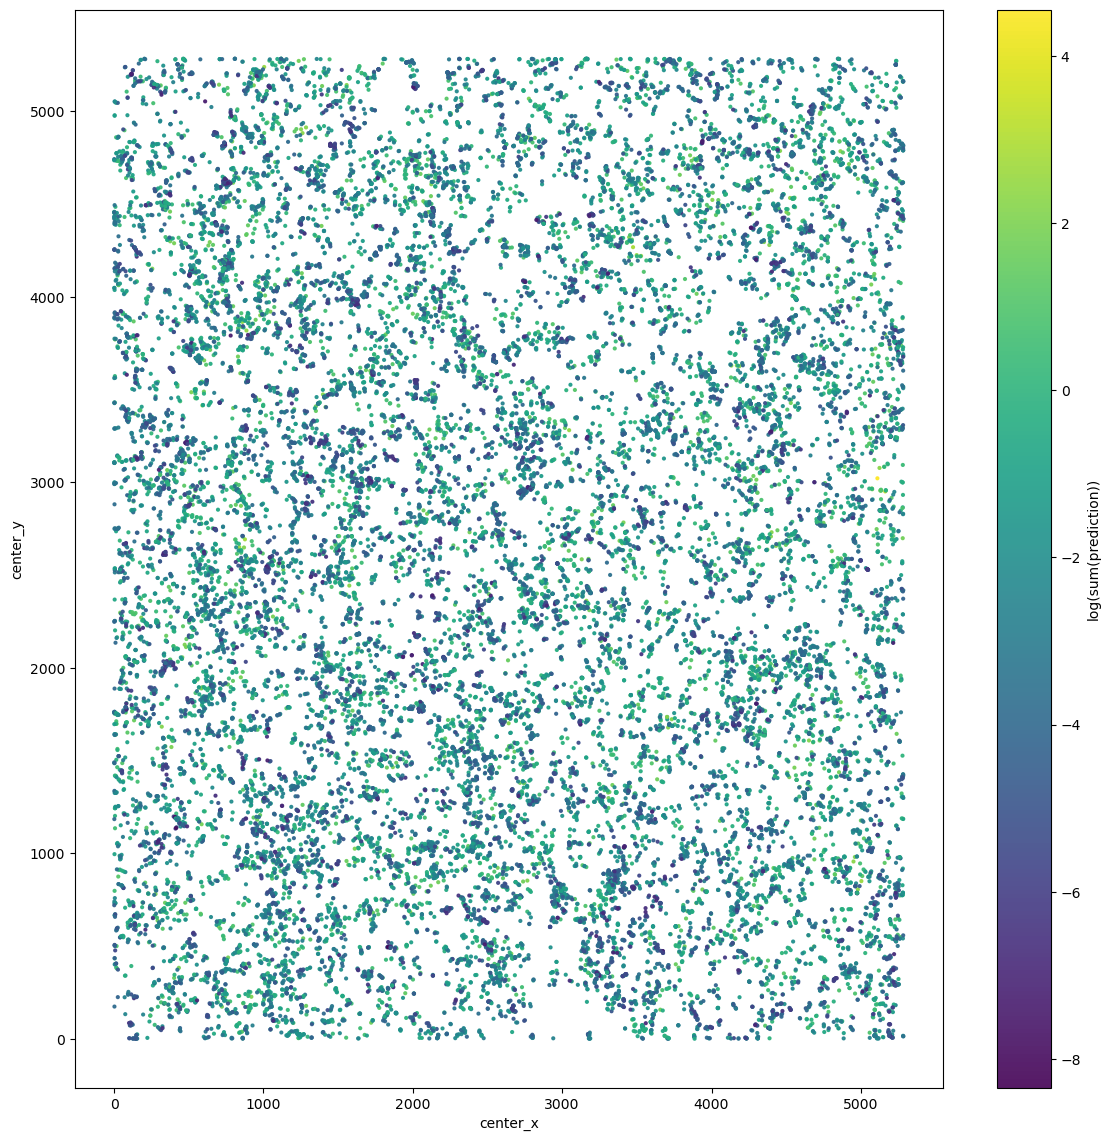

In [39]:
fig, ax = plt.subplots(figsize=(14, 14))

df = (
    pred_list[6]
    .groupby('track_index')
    .agg({
        'center_x': 'mean',
        'center_y': 'mean',
        'prediction': lambda x: np.log(np.sum(x))
    })
)

sc = ax.scatter(
    df['center_x'],
    df['center_y'],
    c=df['prediction'],
    s=4,
    alpha=0.9
)

plt.colorbar(sc, ax=ax, label='log(sum(prediction))')
ax.set_xlabel('center_x')
ax.set_ylabel('center_y')

plt.show()


<Axes: xlabel='center_x', ylabel='center_y'>

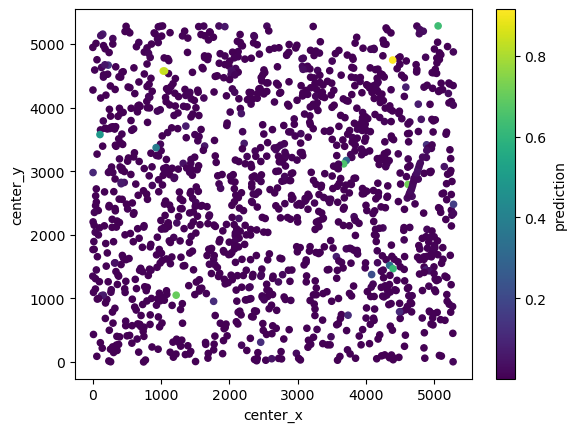

In [11]:
pred_list[3][pred_list[3]['time_point_index']==119].plot.scatter(x='center_x', y='center_y', c='prediction')

In [2]:
tracks = pd.read_csv('/mnt/data/2026-01-14-gas_dko.csv')

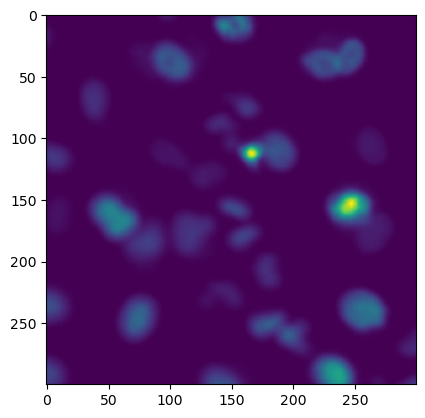

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image_path = '/mnt/nas/operetta/pkaczyns/2026-01-14-namirine-Gas_DKO/0202-Remixes/Img_t0001--H2B.png'
image = mpimg.imread(image_path)
plt.imshow(image[-300:,:300])
plt.show()


[  0.          44.72135955  63.2455532   77.45966692  89.4427191
 100.         109.5445115  118.32159566 126.49110641 134.16407865
 141.42135624 148.32396974 154.91933385 161.24515497 167.33200531
 173.20508076 178.8854382  184.39088915 189.73665961 194.9358869
 200.        ]


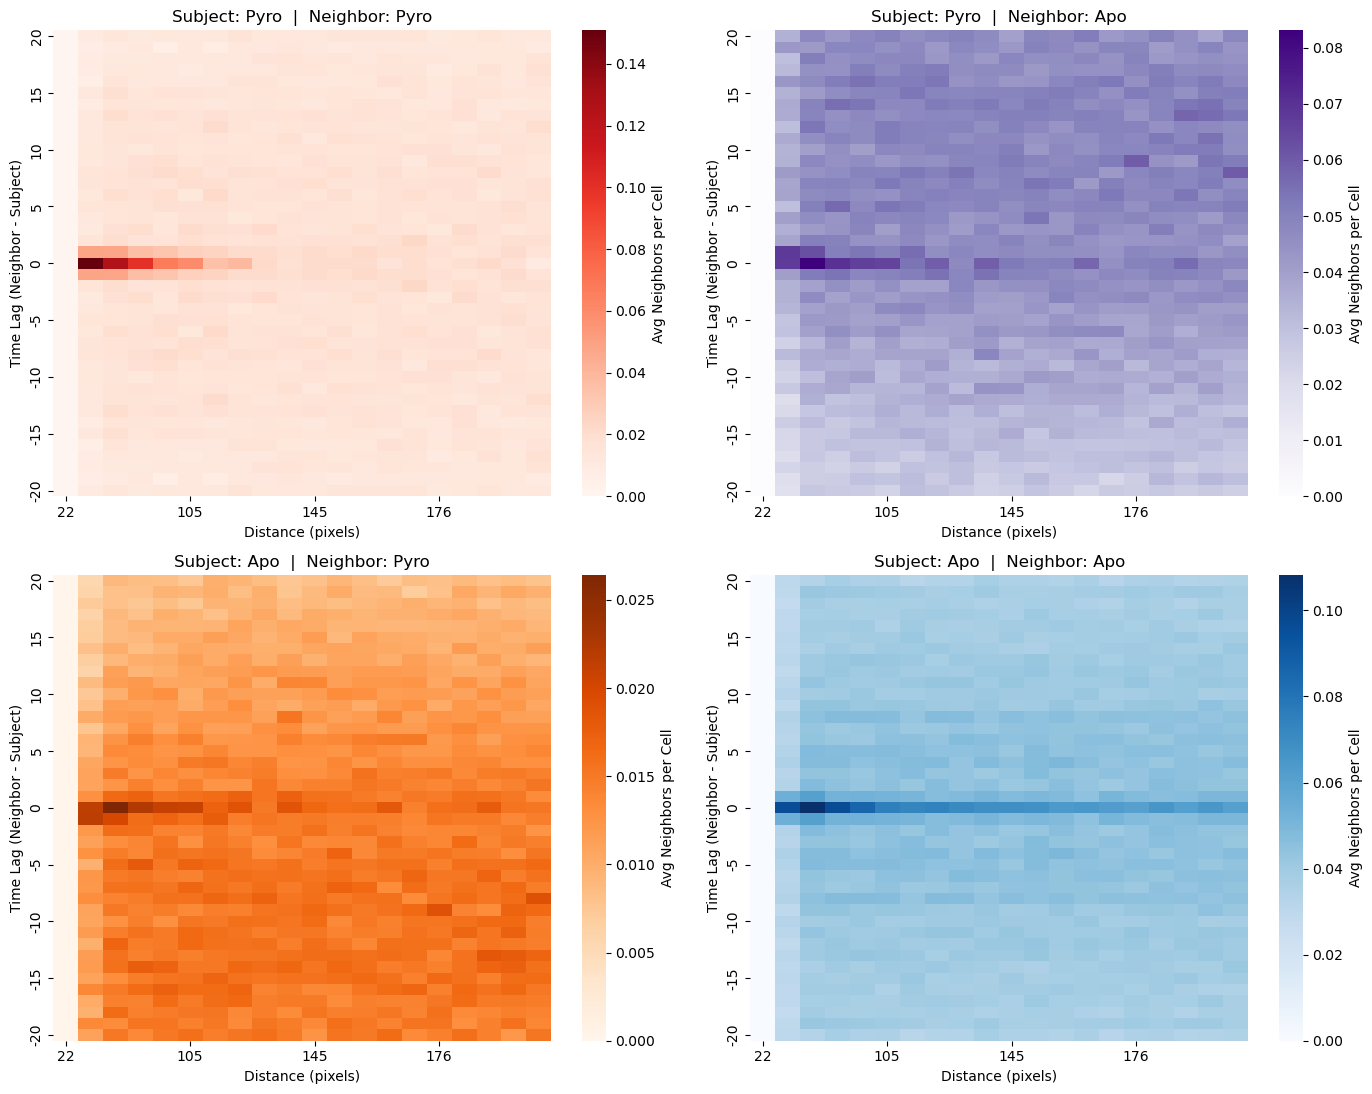

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

def compute_spatiotemporal_density(subject_df, neighbor_df, 
                                   dist_bins, time_bins, 
                                   min_dist=50):
    """
    Computes the 2D histogram of neighbor density (Time vs Distance).
    Returns the normalized heatmap grid (Avg neighbors per subject).
    """
    if len(subject_df) == 0 or len(neighbor_df) == 0:
        return np.zeros((len(time_bins)-1, len(dist_bins)-1))

    # 1. Get Coordinates and Times
    sub_coords = subject_df[['center_x', 'center_y']].values
    nbr_coords = neighbor_df[['center_x', 'center_y']].values
    
    sub_times = subject_df['time_point_index'].values
    nbr_times = neighbor_df['time_point_index'].values
    
    # 2. Calculate Pairwise Spatial Distances (Subject vs Neighbor)
    # Shape: (N_subjects, N_neighbors)
    dists = cdist(sub_coords, nbr_coords)
    
    # 3. Calculate Pairwise Time Differences (Neighbor - Subject)
    # Positive means Neighbor died AFTER Subject
    # Shape: (N_subjects, N_neighbors) using broadcasting
    time_diffs = nbr_times[None, :] - sub_times[:, None]
    
    # 4. Flatten for Histogramming
    flat_dists = dists.ravel()
    flat_times = time_diffs.ravel()
    # 5. Filter for Min Distance (Exclude self-matches and split artifacts)
    # We only keep pairs where distance > min_dist
    mask = flat_dists > min_dist
    
    # 6. Compute 2D Histogram
    # This counts how many pairs fall into each (Distance, Time) bin
    heatmap, _, _ = np.histogram2d(
        flat_times[mask], 
        flat_dists[mask], 
        bins=[time_bins, dist_bins]
    )
    
    # 7. Normalize
    # We want "Average Neighbors per Subject", not "Total Pairs"
    # So we divide by the number of Subject cells
    heatmap_norm = heatmap / len(subject_df)
    
    return heatmap_norm

def plot_interaction_heatmaps(tracks_df, pred_col='prediction', threshold=0.5, 
                              max_dist=300, min_dist=50, max_time_lag=50):
    
    # Define Bins
    # Distance: 0 to 300 pixels, step of 10
    dist_bins = np.linspace(0, max_dist, 31) 
    ds = []
    r = 0
    C = 2000
    while r<max_dist:
        ds.append(r)
        r =np.sqrt(r**2+C)
        
    dist_bins = np.array(ds)
    print(dist_bins)
    # Time: -50 to +50 frames, step of 2
    time_bins = np.linspace(-max_time_lag, max_time_lag, 2*max_time_lag+2)
    
    # Prepare Labels for Plotting
    # We use the centers of bins for axes
    x_labels = np.round((dist_bins[:-1] + dist_bins[1:]) / 2).astype(int)
    y_labels = np.round((time_bins[:-1] + time_bins[1:]) / 2).astype(int)
    
    # Loop through wells
    grouped = tracks_df.groupby(['well', 'Compound', 'Cell Type'])
    
    for (well, compound, cell_type), group in grouped:

        #group = tracks_df
        if len(group) < 1000: continue
        
        print(f"Processing {well} - {compound}... {len(group)}")
        
        # Split Data
        pyro_df = group[group[pred_col] > threshold]
        apo_df = group[group[pred_col] <= threshold]
        
        # We need 4 matrices
        matrices = {}
        
        # 1. Subject: Pyro, Neighbor: Pyro
        matrices['Pyro -> Pyro'] = compute_spatiotemporal_density(pyro_df, pyro_df, dist_bins, time_bins)
        
        # 2. Subject: Pyro, Neighbor: Apo
        matrices['Pyro -> Apo'] = compute_spatiotemporal_density(pyro_df, apo_df, dist_bins, time_bins)
        
        # 3. Subject: Apo, Neighbor: Pyro
        matrices['Apo -> Pyro'] = compute_spatiotemporal_density(apo_df, pyro_df, dist_bins, time_bins)
        
        # 4. Subject: Apo, Neighbor: Apo
        matrices['Apo -> Apo'] = compute_spatiotemporal_density(apo_df, apo_df, dist_bins, time_bins)
        
        # --- Plotting ---
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        #fig.suptitle(f"Spatiotemporal Density: {well}\n{compound} ({cell_type})", fontsize=16)
        
        plot_configs = [
            (axes[0,0], 'Pyro -> Pyro', 'Reds'),
            (axes[0,1], 'Pyro -> Apo', 'Purples'),
            (axes[1,0], 'Apo -> Pyro', 'Oranges'),
            (axes[1,1], 'Apo -> Apo', 'Blues')
        ]
        
        # Determine global max for color scaling (optional, but helps comparison)
        # vmax = max([m.max() for m in matrices.values()])
        
        for ax, key, cmap in plot_configs:
            data = matrices[key]
            
            # Using dataframe for easy heatmap labeling
            df_plot = pd.DataFrame(data, index=y_labels, columns=x_labels)
            
            # Since index is high-to-low in image coords, we usually flip or let seaborn handle it
            # Seaborn puts index 0 at top. Our time bins go -50 (top) to +50 (bottom).
            # Actually standard plots have Y increasing upwards. 
            # Let's invert the Y-axis index so +Time is at top.
            df_plot = df_plot.iloc[::-1] 
            
            sns.heatmap(df_plot, ax=ax, cmap=cmap, 
                        cbar_kws={'label': 'Avg Neighbors per Cell'},
                        xticklabels=5, yticklabels=5) # Show every 5th label
            
            ax.set_title(f"Subject: {key.split(' -> ')[0]}  |  Neighbor: {key.split(' -> ')[1]}")
            ax.set_xlabel("Distance (pixels)")
            ax.set_ylabel("Time Lag (Neighbor - Subject)")
            #ax.se
            # Draw crosshairs at (0,0)
            # Find approximate index of 0 time and 0 distance not needed visually for bins
            # Just drawing lines at the "Zero" ticks if possible, but heatmap is categorical axes
            # We can imply it by the labels.
            
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# --- Run ---
plot_interaction_heatmaps(tracks[(tracks['track_length']>15)&(tracks['track_length']<110)], pred_col='prediction', threshold=0.5, max_dist=200, max_time_lag=20)

Pyro events: 4932, Apo events: 15516
Log Scale Range: 0.00009 to 0.00390


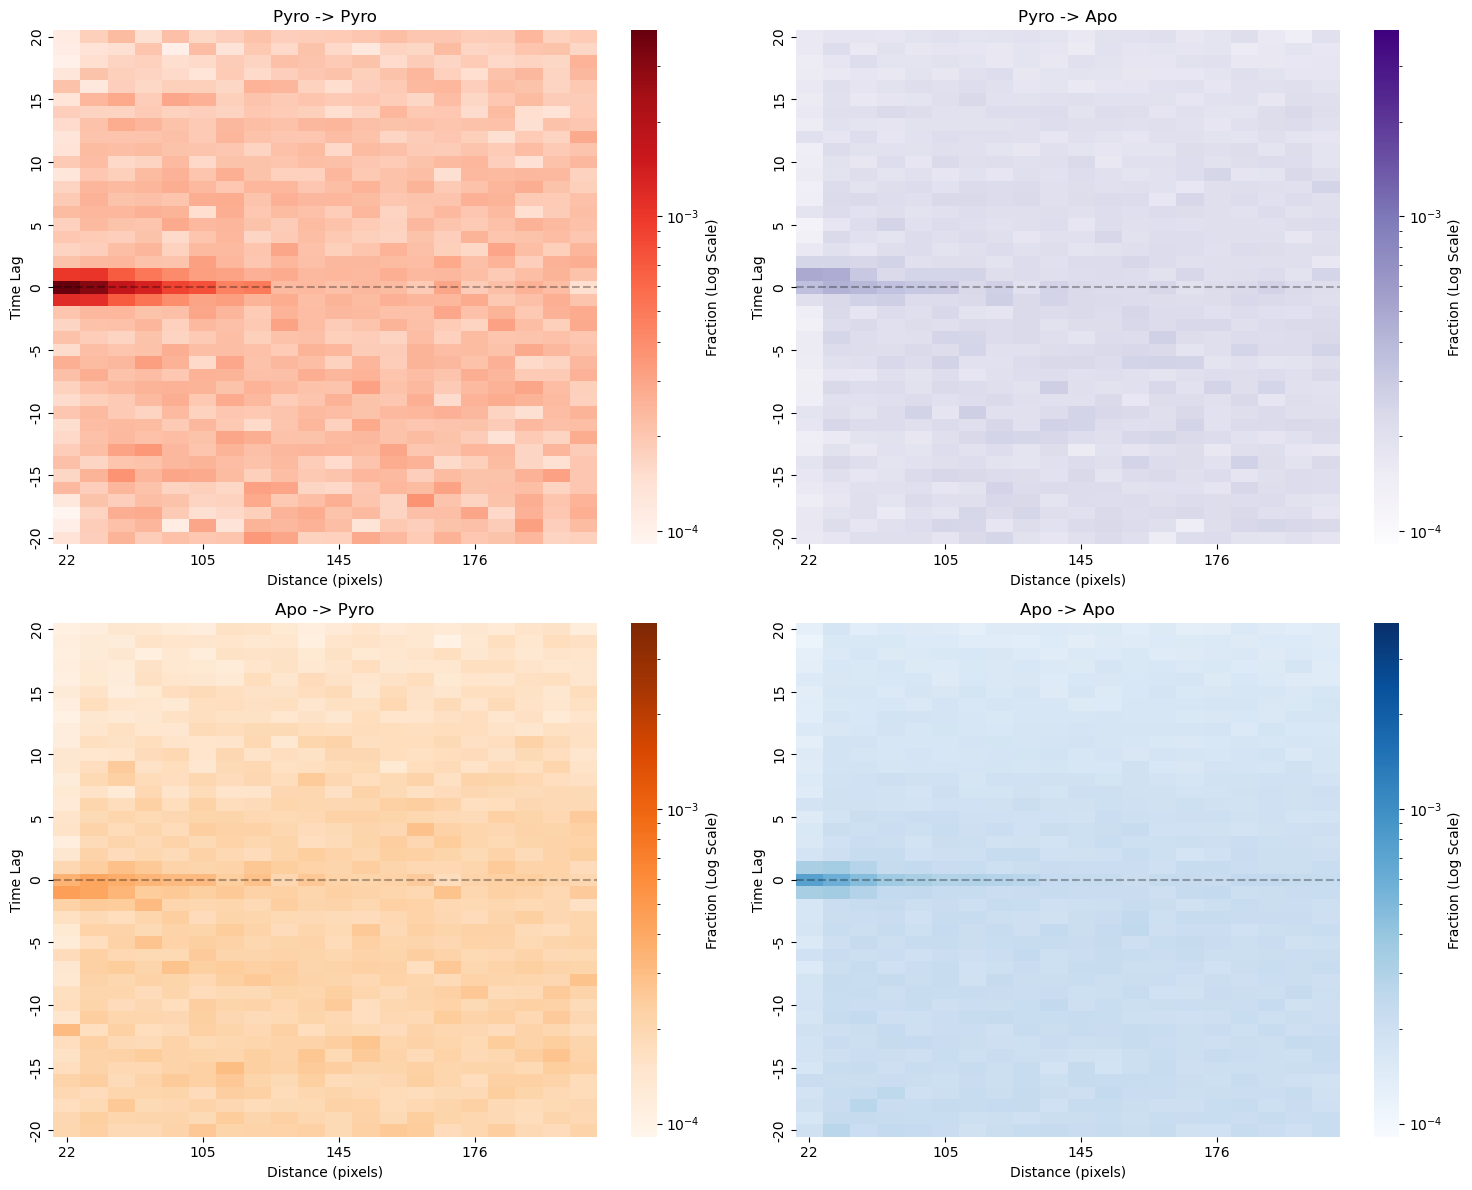

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from matplotlib.colors import LogNorm  # <--- Crucial import for Log Scale

def compute_spatiotemporal_density(subject_df, neighbor_df, 
                                   dist_bins, time_bins, 
                                   min_dist=50):
    """
    Computes the 2D histogram of neighbor density (Time vs Distance).
    """
    if len(subject_df) == 0 or len(neighbor_df) == 0:
        return np.zeros((len(time_bins)-1, len(dist_bins)-1))

    # 1. Get Coordinates and Times
    sub_coords = subject_df[['center_x', 'center_y']].values
    nbr_coords = neighbor_df[['center_x', 'center_y']].values
    
    sub_times = subject_df['time_point_index'].values
    nbr_times = neighbor_df['time_point_index'].values
    
    # 2. Weights: Inverse Frequency Normalization
    frame_counts = neighbor_df['time_point_index'].value_counts().sort_index()
    # Handle missing frames (if a neighbor exists at a time not in index - rare but possible)
    # We reindex to ensure we cover the range
    global_counts_at_nbr_time = frame_counts.reindex(nbr_times, fill_value=1).values
    
    # Avoid division by zero (safety)
    global_counts_at_nbr_time[global_counts_at_nbr_time == 0] = 1
    nbr_weights = 1.0 / global_counts_at_nbr_time
    
    # 3. Calculate Distances and Times
    dists = cdist(sub_coords, nbr_coords)
    time_diffs = nbr_times[None, :] - sub_times[:, None]
    weights_matrix = np.tile(nbr_weights, (len(subject_df), 1))
    
    # 4. Flatten
    flat_dists = dists.ravel()
    flat_times = time_diffs.ravel()
    flat_weights = weights_matrix.ravel()
    
    # 5. Filter for Min Distance
    mask = flat_dists > min_dist
    
    # 6. Compute 2D Histogram
    heatmap, _, _ = np.histogram2d(
        flat_times[mask], 
        flat_dists[mask], 
        bins=[time_bins, dist_bins],
        weights=flat_weights[mask]
    )
    
    # 7. Normalize per subject
    heatmap_norm = heatmap / len(subject_df)
    
    return heatmap_norm

def plot_interaction_heatmaps(tracks_df, pred_col='prediction', threshold=0.5, 
                              max_dist=300, min_dist=50, max_time_lag=50):
    
    # Define Variable Width Distance Bins
    ds = []
    r = 0
    C = 2000
    while r < max_dist:
        ds.append(r)
        r = np.sqrt(r**2 + C)
    dist_bins = np.array(ds)
    
    # Time Bins
    time_bins = np.linspace(-max_time_lag, max_time_lag, 2*max_time_lag+2)
    
    # Labels
    x_labels = np.round((dist_bins[:-1] + dist_bins[1:]) / 2).astype(int)
    y_labels = np.round((time_bins[:-1] + time_bins[1:]) / 2).astype(int)
    
    # Group logic (assuming single well for now based on previous context)
    if True:
        group = tracks_df.copy()
        
        # Split Data
        pyro_df = group[group[pred_col] > threshold]
        apo_df = group[group[pred_col] <= threshold]
        
        print(f"Pyro events: {len(pyro_df)}, Apo events: {len(apo_df)}")
        
        # --- 1. Compute All Matrices ---
        matrices = {}
        
        matrices['Pyro -> Pyro'] = compute_spatiotemporal_density(
            pyro_df, pyro_df, dist_bins, time_bins, min_dist=min_dist)
        
        matrices['Pyro -> Apo'] = compute_spatiotemporal_density(
            pyro_df, apo_df, dist_bins, time_bins, min_dist=min_dist)
        
        matrices['Apo -> Pyro'] = compute_spatiotemporal_density(
            apo_df, pyro_df, dist_bins, time_bins, min_dist=min_dist)
        
        matrices['Apo -> Apo'] = compute_spatiotemporal_density(
            apo_df, apo_df, dist_bins, time_bins, min_dist=min_dist)
        
        # --- 2. Determine Common Log Scale Limits ---
        # Concatenate all data to find min/max
        all_data = np.concatenate([m.flatten() for m in matrices.values()])
        
        # Filter strictly positive values for Log Scale
        positive_data = all_data[all_data > 0]
        
        if len(positive_data) > 0:
            vmin = positive_data.min()
            vmax = positive_data.max()
        else:
            vmin, vmax = 0.001, 1.0 # Fallback if empty
            
        print(f"Log Scale Range: {vmin:.5f} to {vmax:.5f}")
        
        # --- 3. Plotting ---
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Using a unified colormap (e.g., 'magma' or 'viridis') allows true comparison.
        # If you prefer keeping Reds/Blues, we can do that, but 'magma' is better for log details.
        # I will keep your requested distinct colors but enforce the range.
        plot_configs = [
            (axes[0,0], 'Pyro -> Pyro', 'Reds'),
            (axes[0,1], 'Pyro -> Apo', 'Purples'),
            (axes[1,0], 'Apo -> Pyro', 'Oranges'),
            (axes[1,1], 'Apo -> Apo', 'Blues')
        ]
        
        for ax, key, cmap in plot_configs:
            data = matrices[key]
            
            # Replace 0 with NaN so they don't break LogNorm and show as transparent
            data_plot = data.copy()
            data_plot[data_plot == 0] = np.nan
            
            df_plot = pd.DataFrame(data_plot, index=y_labels, columns=x_labels)
            df_plot = df_plot.iloc[::-1] # Flip Y so +Time is Top
            
            # Heatmap with LogNorm
            # We enforce the SAME vmin and vmax for all 4 plots
            sns.heatmap(df_plot, ax=ax, cmap=cmap, 
                        norm=LogNorm(vmin=vmin, vmax=vmax), # <--- LOG SCALING
                        cbar_kws={'label': 'Fraction (Log Scale)'},
                        xticklabels=5, yticklabels=5)
            
            ax.set_title(f"{key}")
            ax.set_xlabel("Distance (pixels)")
            ax.set_ylabel("Time Lag")
            
            # Visual Guide: Add horizontal line at Time=0
            # Find the row index corresponding to time 0
            # Since we flipped the df, we need to find 0 in the reversed index
            try:
                zero_idx = list(df_plot.index).index(0) # Find position of 0 label
                ax.axhline(zero_idx + 0.5, color='black', linestyle='--', alpha=0.3)
            except ValueError:
                pass # If 0 isn't exactly a bin center
            
        plt.tight_layout()
        plt.show()

# --- Run ---
plot_interaction_heatmaps(
    tracks[(tracks['track_length']>15) & (tracks['track_length']<110)], 
    pred_col='prediction', 
    threshold=0.5, 
    max_dist=200, 
    min_dist=20, 
    max_time_lag=20
)

Processing 204 - pIC 0,1... 7163
Pyro: 2264, Apo: 4899
Total Area Est: 27903286 px^2
Enrichment Range: 0.10x to 23.92x
Running 100 permutations...
..........
Done.


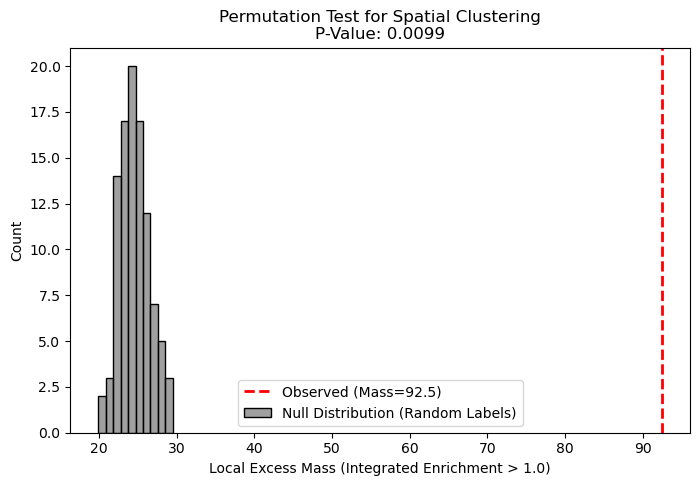

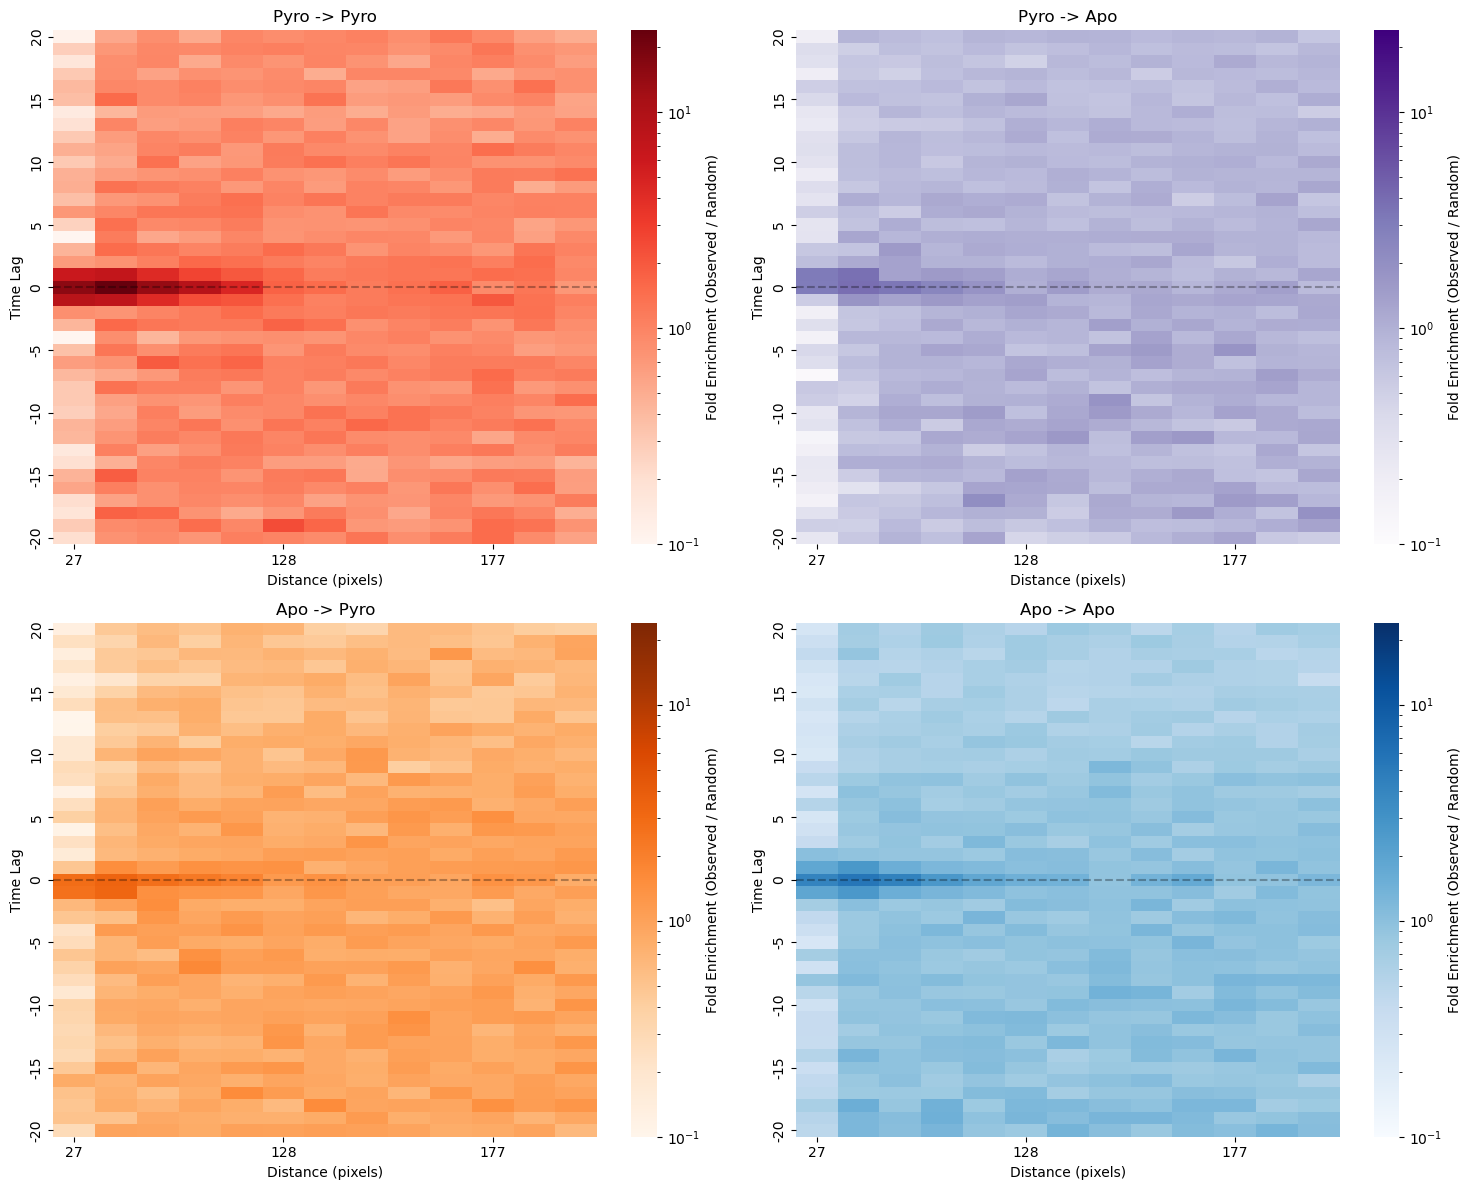

Processing 304 - pIC 0,1... 4197
Pyro: 1501, Apo: 2696
Total Area Est: 27903286 px^2
Enrichment Range: 0.10x to 23.12x
Running 100 permutations...
..........
Done.


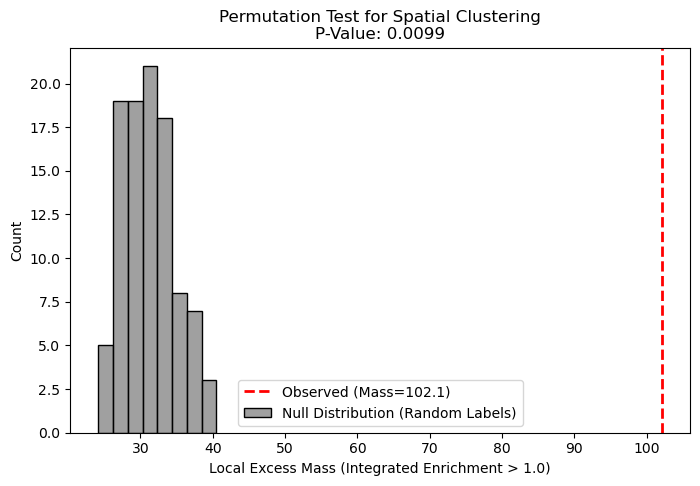

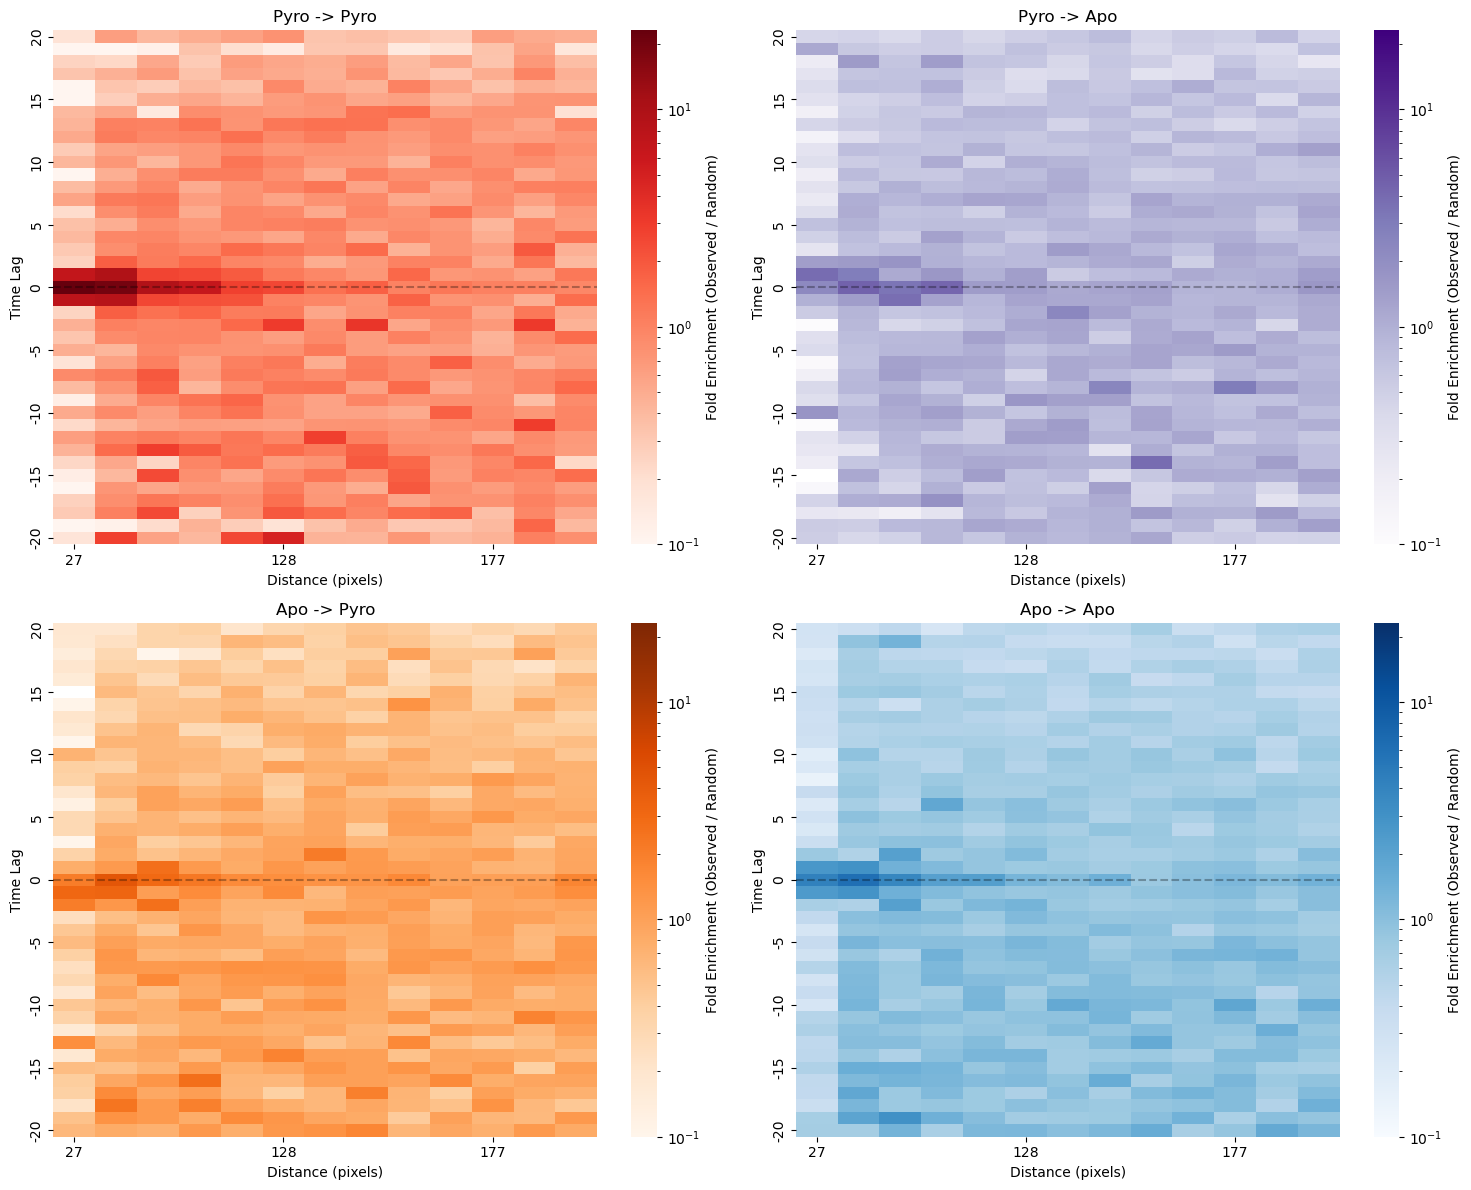

Processing 404 - pIC 0,1... 1749
Pyro: 175, Apo: 1574
Total Area Est: 27903286 px^2
Enrichment Range: 0.10x to 86.23x
Running 100 permutations...
..........
Done.


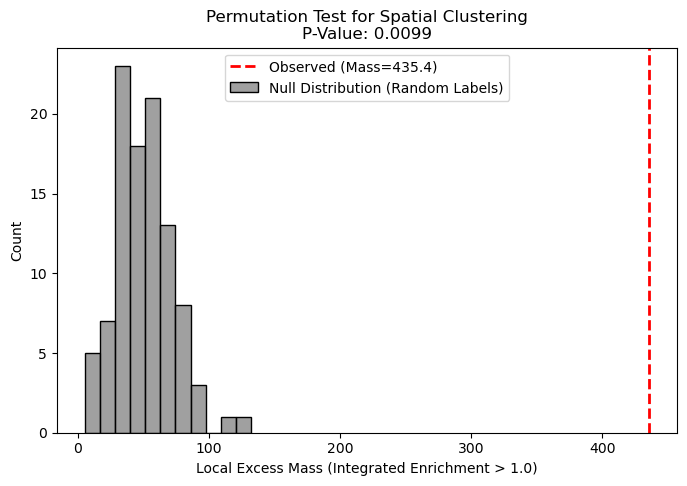

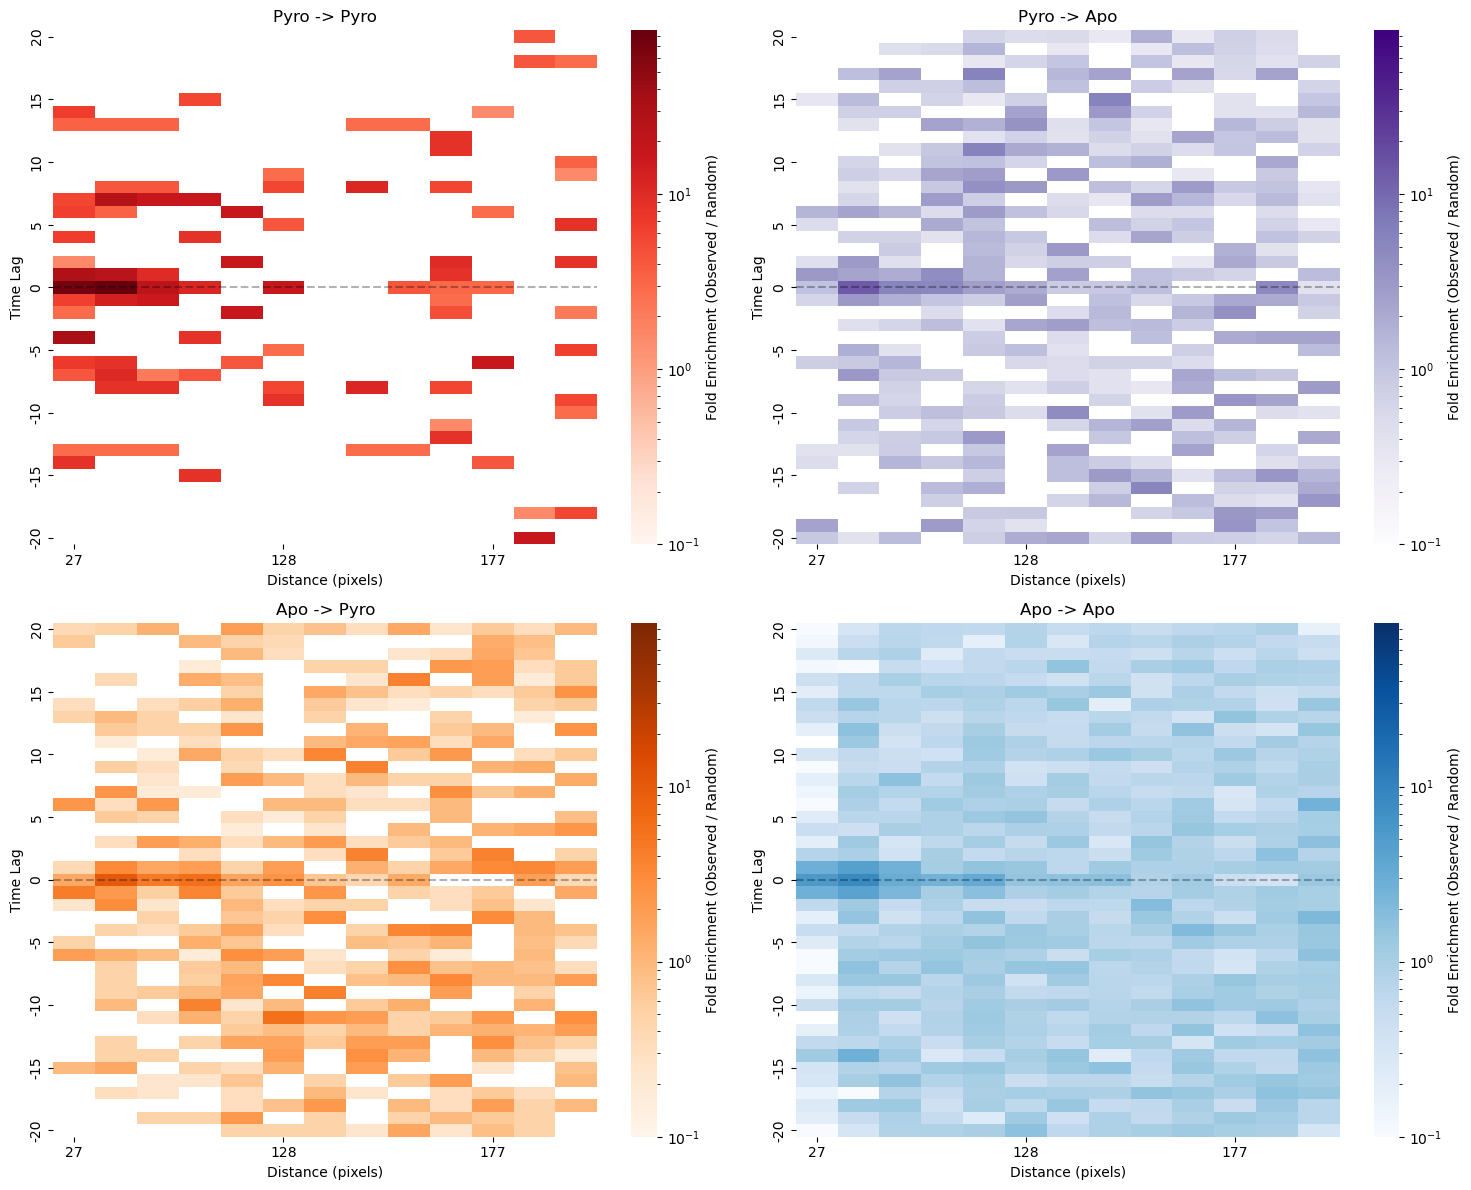

Processing 504 - pIC 0,1... 2808
Pyro: 215, Apo: 2593
Total Area Est: 27903286 px^2
Enrichment Range: 0.10x to 76.49x
Running 100 permutations...
..........
Done.


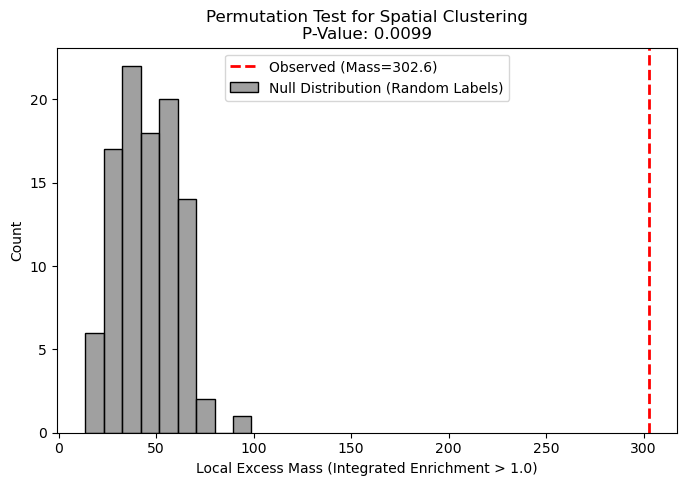

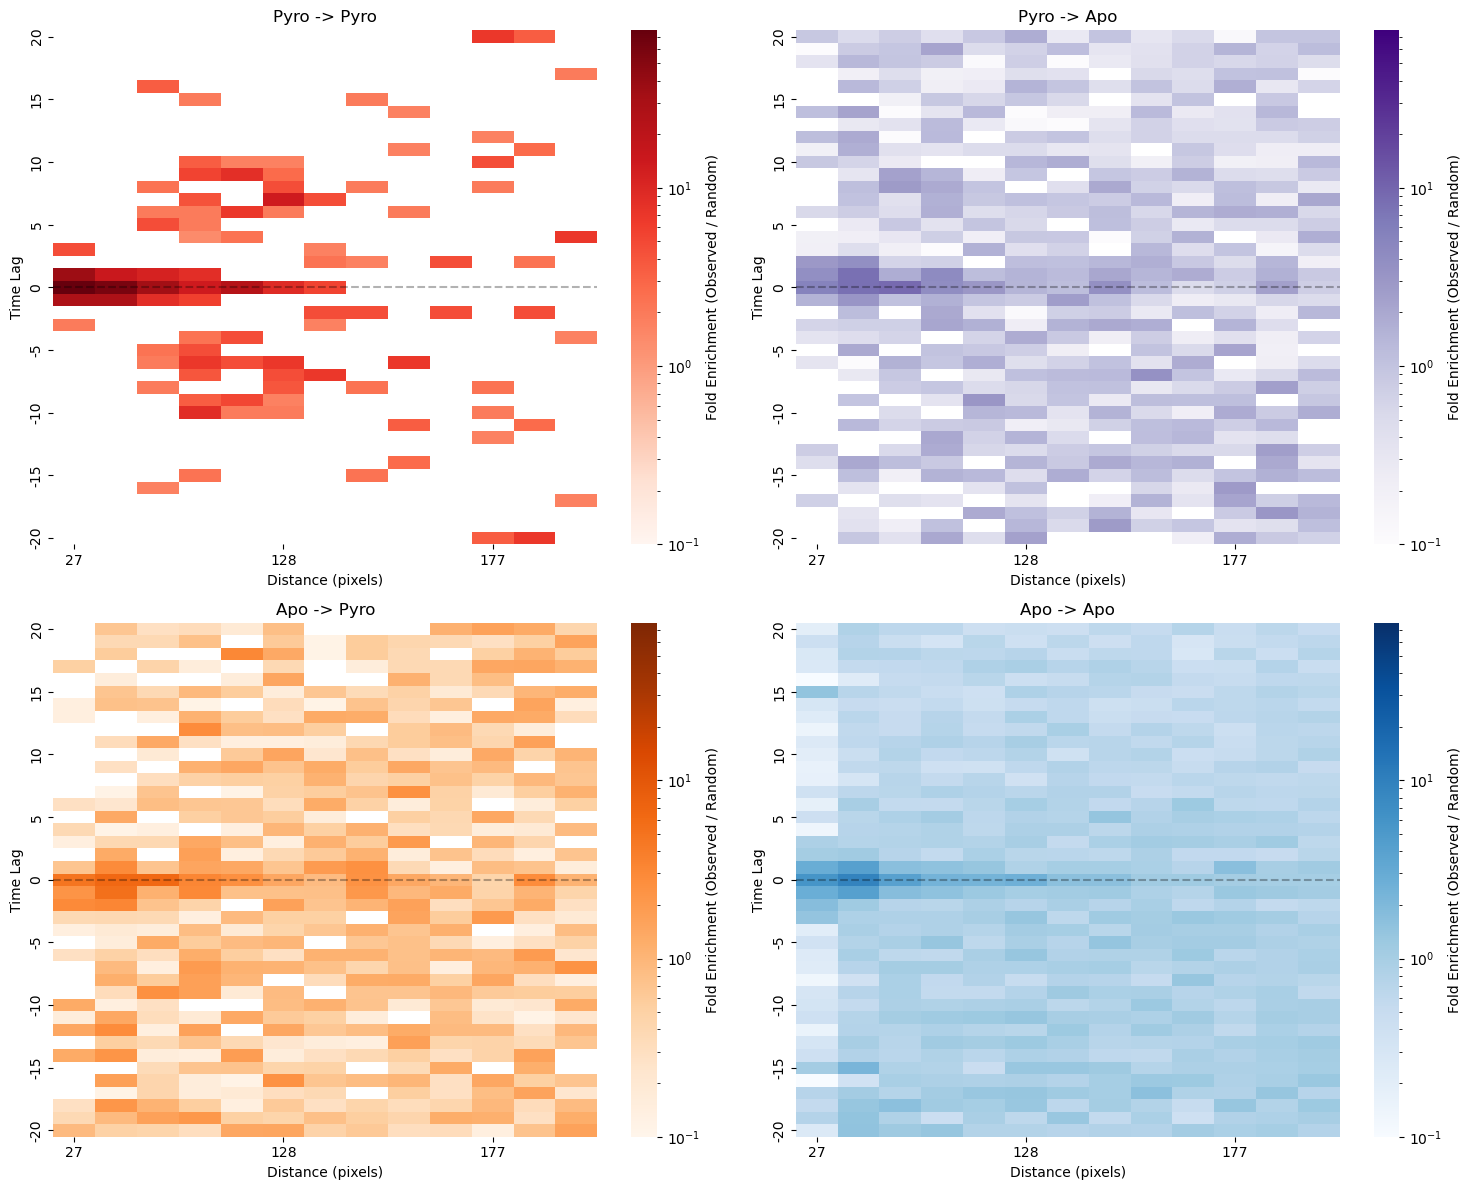

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from matplotlib.colors import LogNorm

def compute_enrichment_heatmap(subject_df, neighbor_df, 
                               dist_bins, time_bins, 
                               total_image_area,
                               min_dist=50):
    """
    Computes the Spatiotemporal Enrichment Heatmap.
    
    Metric: Fold Enrichment (Observed / Expected)
    1. Weighted Count: 1 / (Total Deaths at Time t)
    2. Area Norm: Divide by (Ring Area / Total Image Area)
    """
    if len(subject_df) == 0 or len(neighbor_df) == 0:
        return np.zeros((len(time_bins)-1, len(dist_bins)-1))

    # --- 1. Coordinates and Time ---
    sub_coords = subject_df[['center_x', 'center_y']].values
    nbr_coords = neighbor_df[['center_x', 'center_y']].values
    
    sub_times = subject_df['time_point_index'].values
    nbr_times = neighbor_df['time_point_index'].values
    
    # --- 2. Temporal Weighting (Global Activity Normalization) ---
    # Weight = 1 / (Total deaths of this type in the whole image at this moment)
    frame_counts = neighbor_df['time_point_index'].value_counts().sort_index()
    global_counts_at_nbr_time = frame_counts.reindex(nbr_times, fill_value=1).values
    global_counts_at_nbr_time[global_counts_at_nbr_time == 0] = 1 # Safety
    nbr_weights = 1.0 / global_counts_at_nbr_time
    
    # --- 3. Compute Differences ---
    dists = cdist(sub_coords, nbr_coords)
    time_diffs = nbr_times[None, :] - sub_times[:, None]
    weights_matrix = np.tile(nbr_weights, (len(subject_df), 1))
    
    # --- 4. Histogram (The Observed Fraction) ---
    mask = dists.ravel() > min_dist
    
    heatmap_observed, _, _ = np.histogram2d(
        time_diffs.ravel()[mask], 
        dists.ravel()[mask], 
        bins=[time_bins, dist_bins],
        weights=weights_matrix.ravel()[mask]
    )
    
    # Normalize by number of subjects to get "Avg fraction per subject"
    heatmap_observed /= len(subject_df)
    
    # --- 5. Spatial Area Normalization (The Expected Fraction) ---
    # Calculate Area of each Ring defined by dist_bins
    # Area = pi * (R_outer^2 - R_inner^2)
    r_inner = dist_bins[:-1]
    r_outer = dist_bins[1:]
    ring_areas = np.pi * (r_outer**2 - r_inner**2)
    
    # Calculate what % of the total image this ring occupies
    fraction_of_total_area = ring_areas / total_image_area
    
    # Divide Observed by Expected
    # We divide each column (distance bin) by its specific area fraction
    # Reshape fraction_of_total_area to broadcast correctly: (1, n_dist_bins)
    heatmap_enrichment = heatmap_observed / fraction_of_total_area[None, :]
    
    return heatmap_enrichment

def plot_interaction_heatmaps(tracks_df, pred_col='prediction', threshold=0.5, 
                              max_dist=300, min_dist=50, max_time_lag=50):
    
    # --- 1. Define Bins & Area ---
    # Variable width bins (Constant Area)
    ds = []
    r = 0
    C = 3000 
    while r < max_dist:
        ds.append(r)
        r = np.sqrt(r**2 + C)
    dist_bins = np.array(ds)
    
    time_bins = np.linspace(-max_time_lag, max_time_lag, 2*max_time_lag+2)
    
    x_labels = np.round((dist_bins[:-1] + dist_bins[1:]) / 2).astype(int)
    y_labels = np.round((time_bins[:-1] + time_bins[1:]) / 2).astype(int)
    
    # Estimate Total Image Area (Bounding Box)
    # Ideally, pass the real image dimensions (e.g. 2048*2048)
    # Here we estimate from data extent
    min_x, max_x = tracks_df['center_x'].min(), tracks_df['center_x'].max()
    min_y, max_y = tracks_df['center_y'].min(), tracks_df['center_y'].max()
    total_image_area = (max_x - min_x) * (max_y - min_y)
    
    # Fallback if area is 0 or singular
    if total_image_area <= 0: total_image_area = 2000*2000 

    grouped = tracks_df.groupby(['well', 'Compound', 'Cell Type'])
    
    for (well, compound, cell_type), group in grouped:

        #group = tracks_df
        if len(group) < 1000: continue
        
        print(f"Processing {well} - {compound}... {len(group)}")
        #group = tracks_df.copy()
        pyro_df = group[group[pred_col] > threshold]
        apo_df = group[group[pred_col] <= threshold]
        
        print(f"Pyro: {len(pyro_df)}, Apo: {len(apo_df)}")
        print(f"Total Area Est: {int(total_image_area)} px^2")

        # Compute Matrices
        matrices = {}
        
        # Helper lambda to save typing
        compute_fn = lambda s, n: compute_enrichment_heatmap(
            s, n, dist_bins, time_bins, total_image_area, min_dist=min_dist
        )
        
        matrices['Pyro -> Pyro'] = compute_fn(pyro_df, pyro_df)
        matrices['Pyro -> Apo']  = compute_fn(pyro_df, apo_df)
        matrices['Apo -> Pyro']  = compute_fn(apo_df, pyro_df)
        matrices['Apo -> Apo']   = compute_fn(apo_df, apo_df)
        
        # --- 3. Determine Common Log Scale ---
        # Since 1.0 is the neutral point, we want the range to likely center or encompass 1.
        all_vals = np.concatenate([m.flatten() for m in matrices.values()])
        pos_vals = all_vals[all_vals > 0] # Filter 0/NaN for log calculation
        
        if len(pos_vals) > 0:
            vmin = pos_vals.min()
            vmax = pos_vals.max()
            # Optional: Clip extremely low values to keep the heatmap readable
            # e.g., anything below 0.1 (10x depletion) might be noise
            vmin = max(vmin, 0.1) 
        else:
            vmin, vmax = 0.1, 10.0
        
        print(f"Enrichment Range: {vmin:.2f}x to {vmax:.2f}x")
        p_value, real_mass, nulls = permutation_test_clustering(
            group, 
            pred_col='prediction', 
            dist_bins=dist_bins, 
            time_bins=time_bins, 
            total_area=total_image_area, 
            n_perms=100  # Start with 100 for speed, use 1000 for publication
        )
        # --- 4. Plotting ---
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        plot_configs = [
            (axes[0,0], 'Pyro -> Pyro', 'Reds'),
            (axes[0,1], 'Pyro -> Apo', 'Purples'),
            (axes[1,0], 'Apo -> Pyro', 'Oranges'),
            (axes[1,1], 'Apo -> Apo', 'Blues')
        ]
        
        for ax, key, cmap in plot_configs:
            data = matrices[key].copy()
            data[data == 0] = np.nan
            
            df_plot = pd.DataFrame(data, index=y_labels, columns=x_labels)
            df_plot = df_plot.iloc[::-1] # Flip Time
            
            sns.heatmap(df_plot, ax=ax, cmap=cmap, 
                        norm=LogNorm(vmin=vmin, vmax=vmax), # Common Log Scale
                        cbar_kws={'label': 'Fold Enrichment (Observed / Random)'},
                        xticklabels=5, yticklabels=5)
            
            ax.set_title(f"{key}")
            ax.set_xlabel("Distance (pixels)")
            ax.set_ylabel("Time Lag")
            
            # Reference Lines
            # Time = 0
            try:
                zero_t_idx = list(df_plot.index).index(0)
                ax.axhline(zero_t_idx + 0.5, color='black', linestyle='--', alpha=0.3)
            except: pass
            
        plt.tight_layout()
        plt.show()

# --- Run ---
plot_interaction_heatmaps(
    tracks[(tracks['track_length']>15) & (tracks['track_length']<110)], 
    pred_col='prediction', 
    threshold=0.5, 
    max_dist=200, 
    min_dist=40, 
    max_time_lag=20
)

Running 1000 permutations...
....................................................................................................
Done.


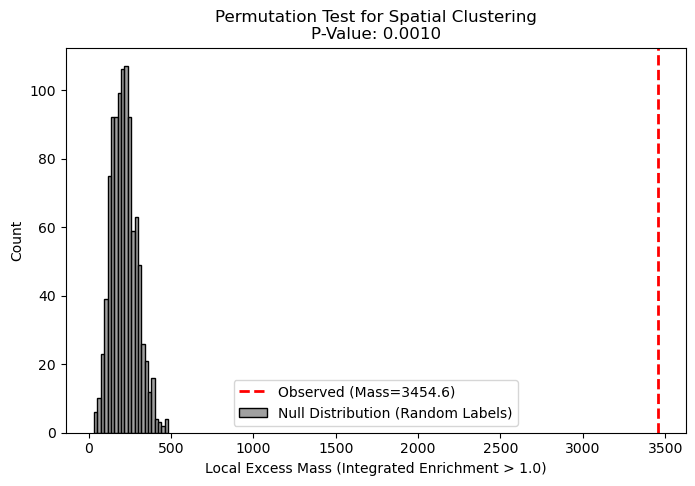

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_hot_zone_mass(heatmap, dist_bins, time_bins, 
                            max_radius=100, max_time=20):
    """
    The Statistic: Sum of enrichment in the 'Causal Near-Field'.
    Radius: 0 to 100 pixels (Immediate neighbors)
    Time: 0 to +20 frames (Casual: Neighbor died AFTER Subject)
    """
    # 1. Identify Bins inside the Hot Zone
    # Dist centers
    d_centers = (dist_bins[:-1] + dist_bins[1:]) / 2
    d_mask = d_centers <= max_radius
    
    # Time centers
    t_centers = (time_bins[:-1] + time_bins[1:]) / 2
    t_mask = (t_centers >= 0) & (t_centers <= max_time)
    
    # 2. Slice the Heatmap
    # Heatmap shape is (n_time, n_dist)
    # We apply the boolean masks to the axes
    hot_zone = heatmap[t_mask, :][:, d_mask]
    
    # 3. Calculate Mass (Sum of Enrichment)
    # We subtract 1.0 because 1.0 is the random baseline.
    # We only care about the *Excess* (Cluster Signal).
    excess = hot_zone - 1.0
    
    # Optional: Clip negative values (depletion) to 0, 
    # so we only measure positive clustering.
    excess[excess < 0] = 0
    
    return np.nansum(excess)

def permutation_test_clustering(df, pred_col, dist_bins, time_bins, total_area, 
                                n_perms=100, threshold=0.5):
    
    # 1. Setup Data
    work_df = df.copy()
    
    # Define the "Real" Pyro subset
    real_pyro = work_df[work_df[pred_col] > threshold]
    
    # 2. Compute REAL Heatmap & Statistic
    real_map = compute_enrichment_heatmap(
        real_pyro, real_pyro, 
        dist_bins, time_bins, total_area, min_dist=20
    )
    
    real_stat = calculate_hot_zone_mass(real_map, dist_bins, time_bins)
    
    # 3. Permutation Loop
    null_stats = []
    print(f"Running {n_perms} permutations...")
    
    # Pre-calculate boolean mask of who is pyro vs not
    # We will shuffle this array, which is much faster than re-thresholding
    is_pyro_array = (work_df[pred_col] > threshold).values
    
    for i in range(n_perms):
        if i % 10 == 0: print(f".", end="")
            
        # --- THE SHUFFLE ---
        # Keep spatial/temporal locations fixed. Shuffle the LABELS.
        # This tests: "Is the clustering due to the *identity* of these cells?"
        shuffled_is_pyro = np.random.permutation(is_pyro_array)
        
        # Create shuffled subset
        # We slice the original DF using the shuffled boolean mask
        perm_pyro = work_df[shuffled_is_pyro]
        
        # Compute Null Heatmap
        null_map = compute_enrichment_heatmap(
            perm_pyro, perm_pyro, 
            dist_bins, time_bins, total_area, min_dist=20
        )
        
        # Compute Null Statistic
        null_stat = calculate_hot_zone_mass(null_map, dist_bins, time_bins)
        null_stats.append(null_stat)
    
    print("\nDone.")
    null_stats = np.array(null_stats)
    
    # 4. Calculate P-Value
    # How many random shuffles produced a cluster as massive as the real one?
    p_val = (np.sum(null_stats >= real_stat) + 1) / (n_perms + 1)
    
    # 5. Visualization
    plt.figure(figsize=(8, 5))
    sns.histplot(null_stats, color='grey', label='Null Distribution (Random Labels)')
    plt.axvline(real_stat, color='red', linestyle='--', linewidth=2, label=f'Observed (Mass={real_stat:.1f})')
    
    plt.title(f"Permutation Test for Spatial Clustering\nP-Value: {p_val:.4f}")
    plt.xlabel("Local Excess Mass (Integrated Enrichment > 1.0)")
    plt.ylabel("Count")
    plt.legend()
    plt.show()
    
    return p_val, real_stat, null_stats

# --------------------------------------------------------
# HOW TO RUN IT
# --------------------------------------------------------

# 1. Pick a specific well (don't mix wells for a permutation test)
# You need a single continuous coordinate system
target_well = tracks[tracks['well'] == tracks['well'].unique()[0]] # Example: First well

# 2. Define your bins (Reuse your existing bin logic)
ds = []
r = 0; C = 2000
while r < 200:
    ds.append(r)
    r = np.sqrt(r**2 + C)
dist_bins = np.array(ds)
time_bins = np.linspace(-20, 20, 41)

# 3. Estimate Area
min_x, max_x = target_well['center_x'].min(), target_well['center_x'].max()
min_y, max_y = target_well['center_y'].min(), target_well['center_y'].max()
area = (max_x - min_x) * (max_y - min_y)

# 4. Run Test
p_value, real_mass, nulls = permutation_test_clustering(
    target_well, 
    pred_col='prediction', 
    dist_bins=dist_bins, 
    time_bins=time_bins, 
    total_area=area, 
    n_perms=1000  # Start with 100 for speed, use 1000 for publication
)

<Axes: >

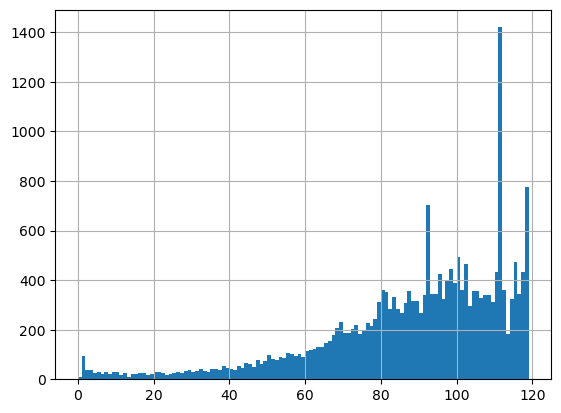

In [13]:
tracks[(tracks.prediction<0.5)&(tracks.track_length>10)].time_point_index.hist(bins=119)

<Axes: >

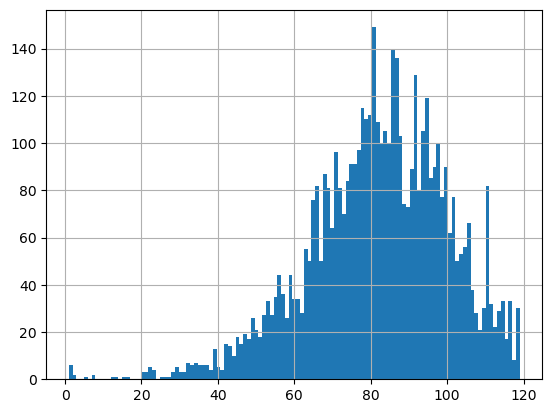

In [11]:
tracks[(tracks.prediction>0.5)&(tracks.track_length>15)].time_point_index.hist(bins=119)

In [18]:
from sklearn.neighbors import NearestNeighbors

def calculate_mean_nn_dist(df):
    # We need at least 2 points to have a neighbor
    if len(df) < 2:
        return np.nan
    
    coords = df[['center_x', 'center_y']].values
    
    # Find 2 nearest neighbors: Index 0 = Self, Index 1 = Real Neighbor
    nbrs = NearestNeighbors(n_neighbors=2).fit(coords)
    distances, _ = nbrs.kneighbors(coords)
    
    # Select the distance to the 2nd point (index 1)
    # distances[:, 0] is always 0.0 (distance to self)
    # distances[:, 1] is distance to the nearest distinct neighbor
    nearest_dists = distances[:, 1]
    
    return np.mean(nearest_dists)
for pl in pred_list:
    print(len(pl[pl['time_point_index']==119]))
    print(calculate_mean_nn_dist(pl[pl['time_point_index']==119]))

364
127.76746312027883
1271
68.92488080403817
8154
34.04432004101699
1393
66.3541526874534
237
154.63089786356866
599
93.13604524563424
0
nan
1284
67.851177646058
349
135.3032508769921
574
95.64310121142894
2296
56.10105089829803
730
86.11507921348944
191
186.422898781203
251
155.6248853580616
3514
47.687016846447726
398
119.902467246152


In [12]:
tracks.groupby(['Cell Type', 'Compound']).count()

Unnamed: 0  track_index  prediction  \
Cell Type    Compound                                              
A549 DKO-6   Cisplatin 10uM        1333         1333        1333   
             IAV MS6 MOI 1          744          744         744   
             mock                   658          658         658   
             pIC 0,1              17548        17548       17548   
A549 GasD KO Cisplatin 10uM        4179         4179        4179   
             IAV MS6 MOI 1         2490         2490        2490   
             mock                  1488         1488        1488   
             pIC 0,1              30465        30465       30465   
A549 GasE KO Cisplatin 10uM        2347         2347        2347   
             IAV MS6 MOI 1         1877         1877        1877   
             mock                  1155         1155        1155   
             pIC 0,1              11678        11678       11678   
A549WT       Cisplatin 10mM        5022         5022        5022   
             IAV MS6 MOI 1         4699         4699        4699   
             mock                  1775         1775        1775   
             pIC 0,1              51965        51965       51965   

                             time_point_index  center_x  center_y  \
Cell Type    Compound                                               
A549 DKO-6   Cisplatin 10uM              1333      1333      1333   
             IAV MS6 MOI 1                744       744       744   
             mock                         658       658       658   
             pIC 0,1                    17548     17548     17548   
A549 GasD KO Cisplatin 10uM              4179      4179      4179   
             IAV MS6 MOI 1               2490      2490      2490   
             mock                        1488      1488      1488   
             pIC 0,1                    30465     30465     30465   
A549 GasE KO Cisplatin 10uM              2347      2347      2347   
             IAV MS6 MOI 1               1877      1877      1877   
             mock                        1155      1155      1155   
             pIC 0,1                    11678     11678     11678   
A549WT       Cisplatin 10mM              5022      5022      5022   
             IAV MS6 MOI 1               4699      4699      4699   
             mock                        1775      1775      1775   
             pIC 0,1                    51965     51965     51965   

                             track_length   well  
Cell Type    Compound                             
A549 DKO-6   Cisplatin 10uM          1333   1333  
             IAV MS6 MOI 1            744    744  
             mock                     658    658  
             pIC 0,1                17548  17548  
A549 GasD KO Cisplatin 10uM          4179   4179  
             IAV MS6 MOI 1           2490   2490  
             mock                    1488   1488  
             pIC 0,1                30465  30465  
A549 GasE KO Cisplatin 10uM          2347   2347  
             IAV MS6 MOI 1           1877   1877  
             mock                    1155   1155  
             pIC 0,1                11678  11678  
A549WT       Cisplatin 10mM          5022   5022  
             IAV MS6 MOI 1           4699   4699  
             mock                    1775   1775  
             pIC 0,1                51965  51965

Analyzing: (np.int64(202), 'mock', 'A549WT')


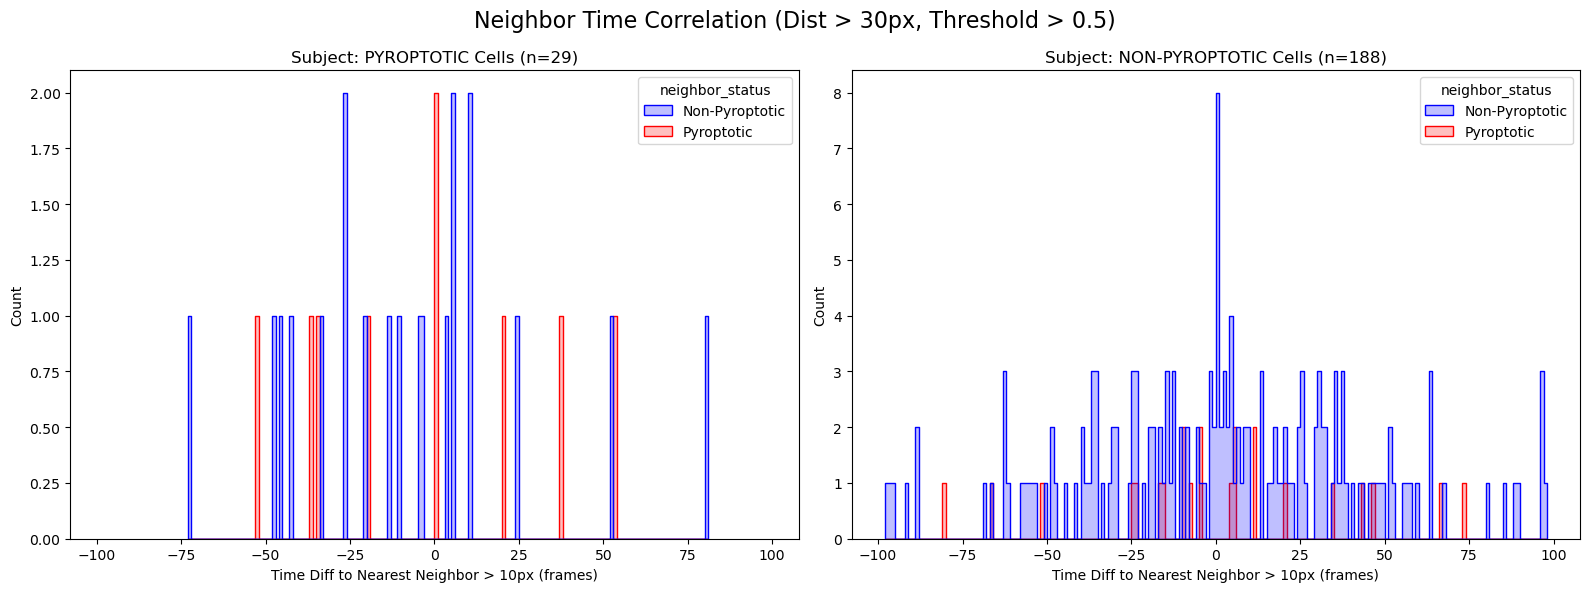

Analyzing: (np.int64(203), 'IAV MS6 MOI 1', 'A549WT')


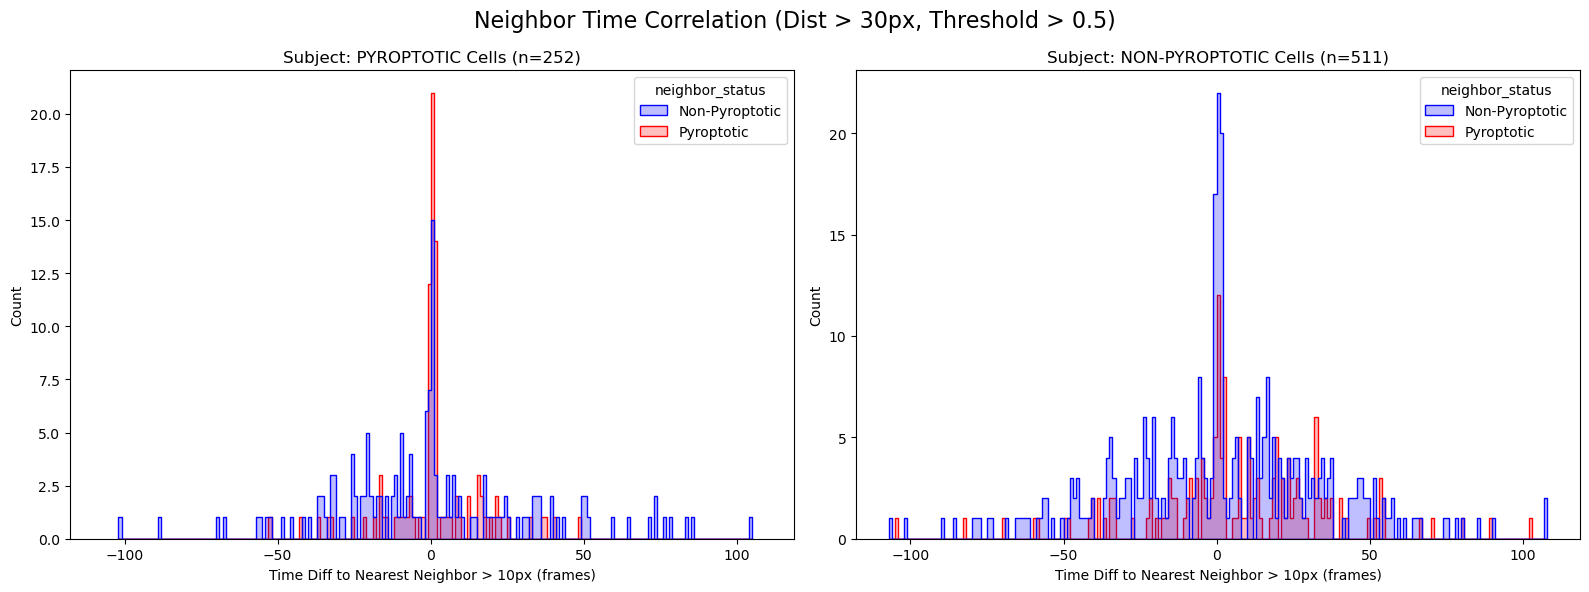

Analyzing: (np.int64(204), 'pIC 0,1', 'A549WT')


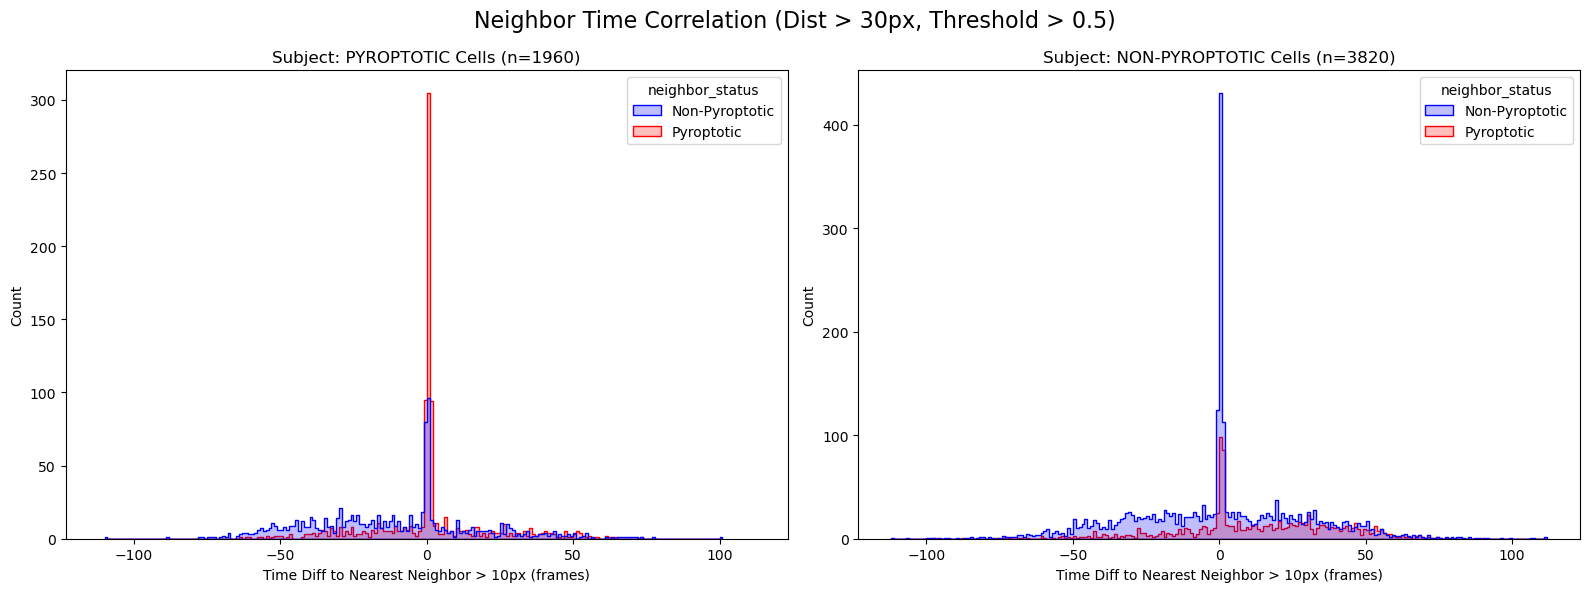

Analyzing: (np.int64(205), 'Cisplatin 10mM', 'A549WT')


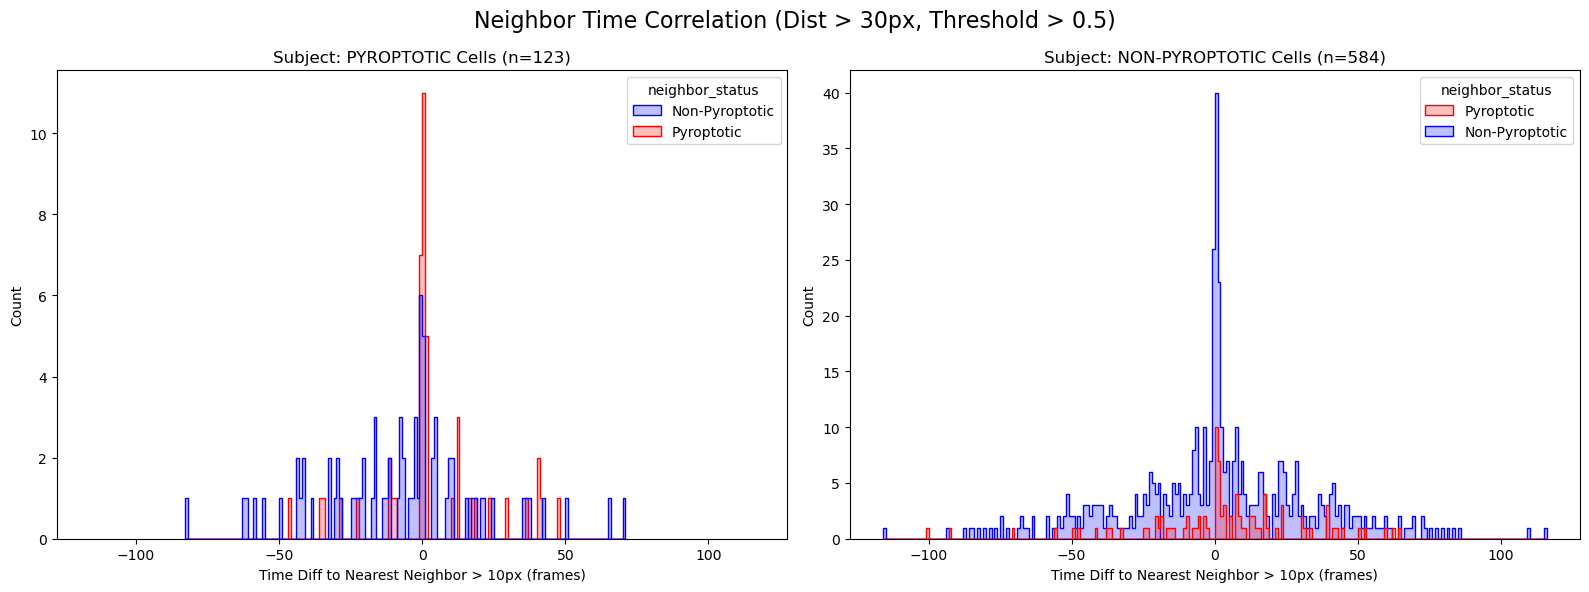

Analyzing: (np.int64(302), 'mock', 'A549 GasD KO')


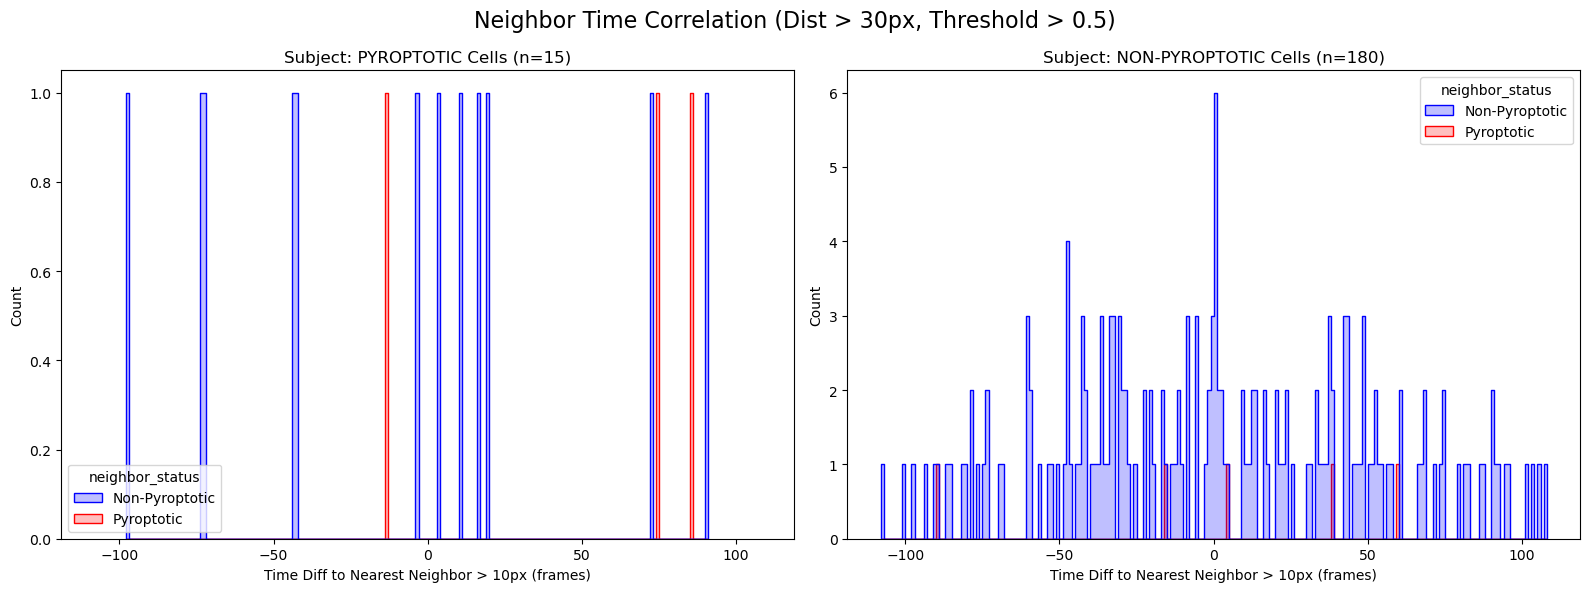

Analyzing: (np.int64(303), 'IAV MS6 MOI 1', 'A549 GasD KO')


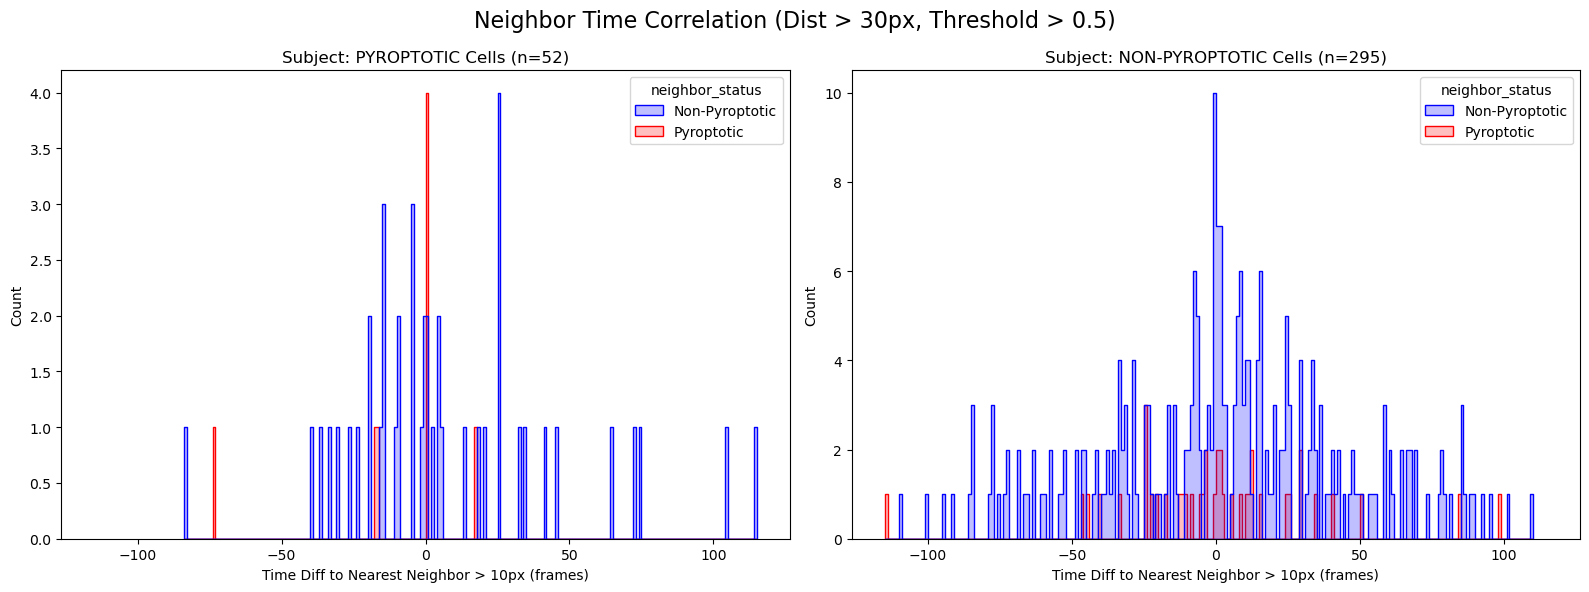

Analyzing: (np.int64(304), 'pIC 0,1', 'A549 GasD KO')


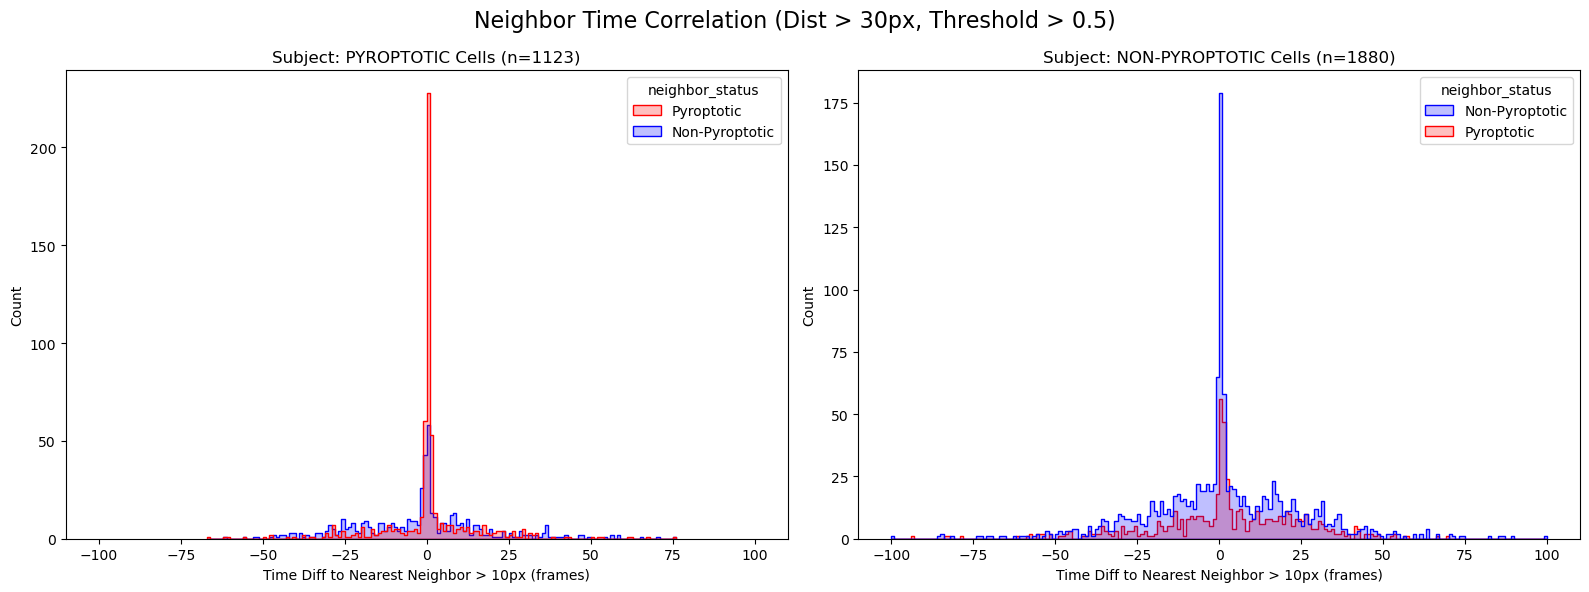

Analyzing: (np.int64(305), 'Cisplatin 10uM', 'A549 GasD KO')


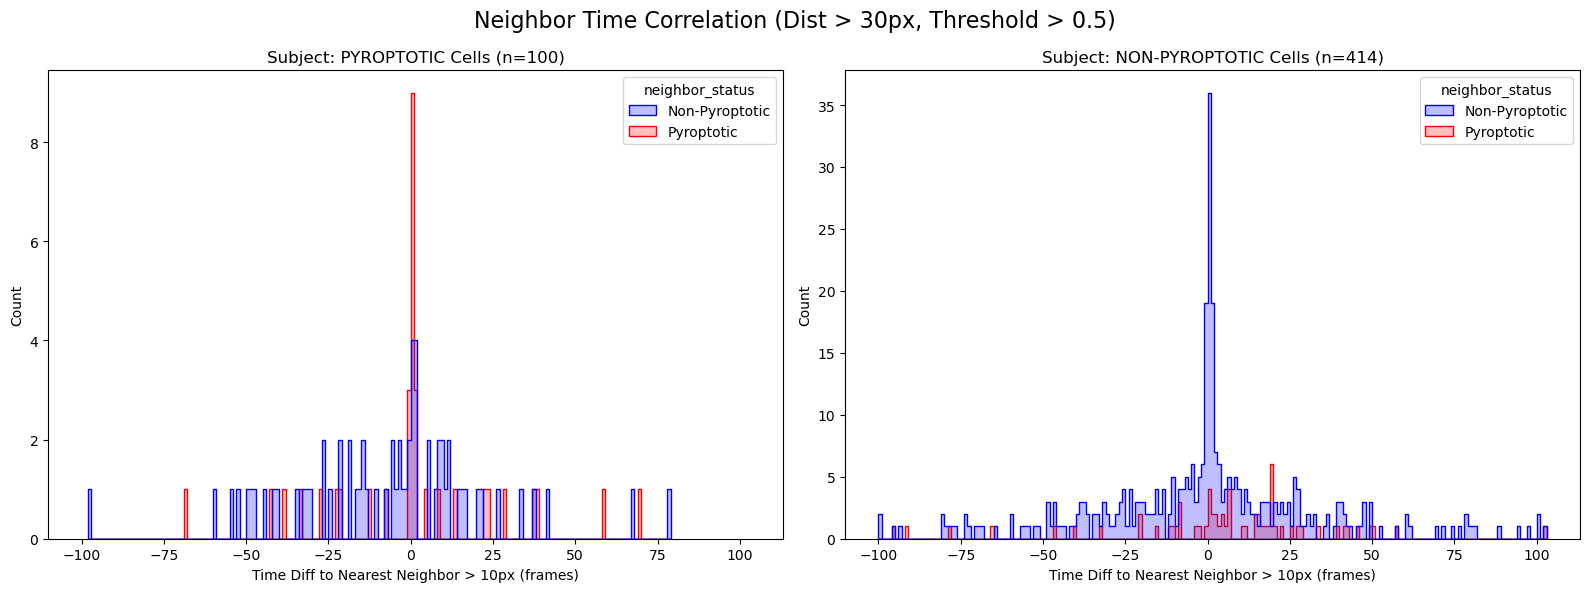

Analyzing: (np.int64(402), 'mock', 'A549 GasE KO')


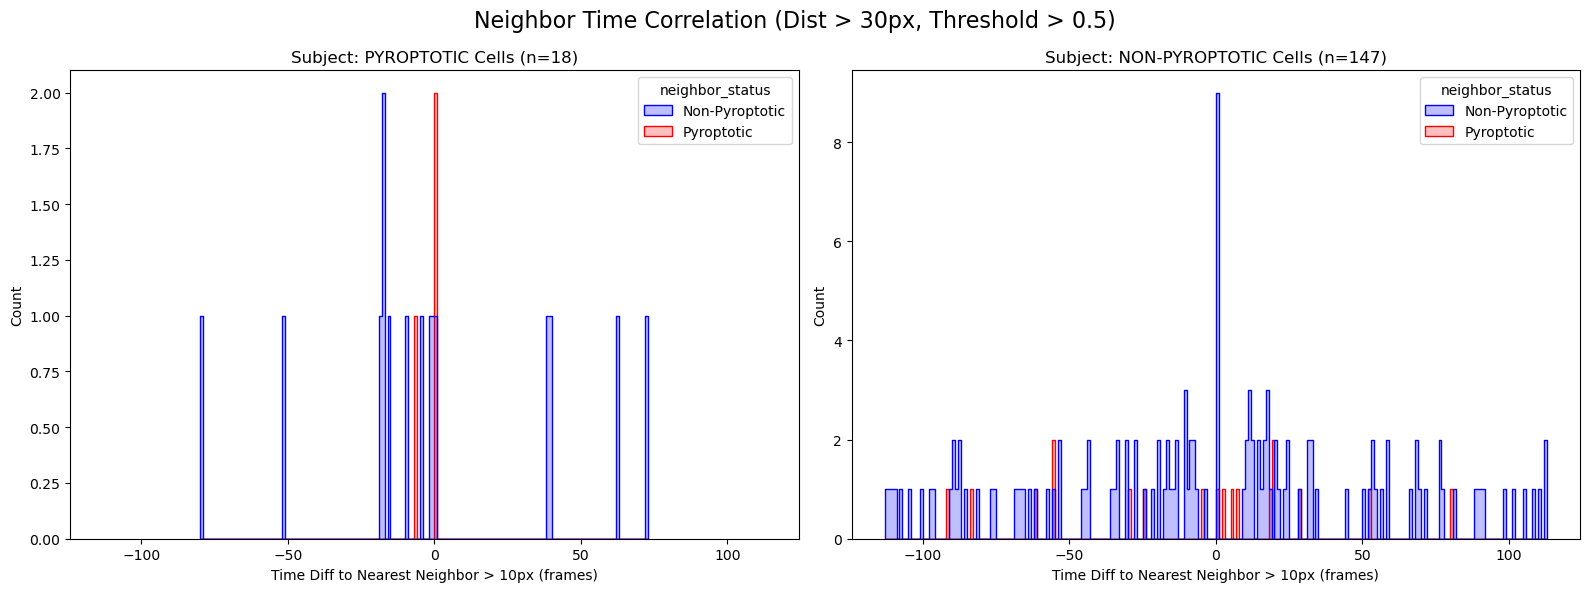

Analyzing: (np.int64(403), 'IAV MS6 MOI 1', 'A549 GasE KO')


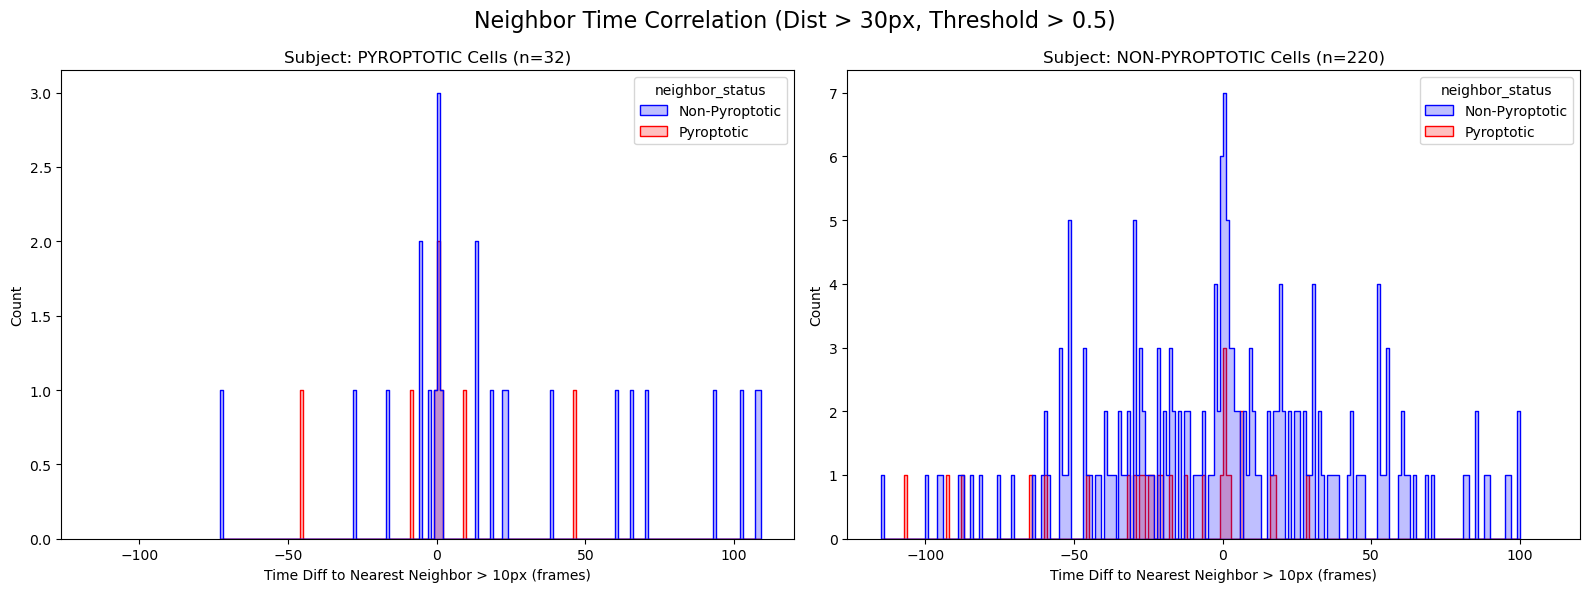

Analyzing: (np.int64(404), 'pIC 0,1', 'A549 GasE KO')


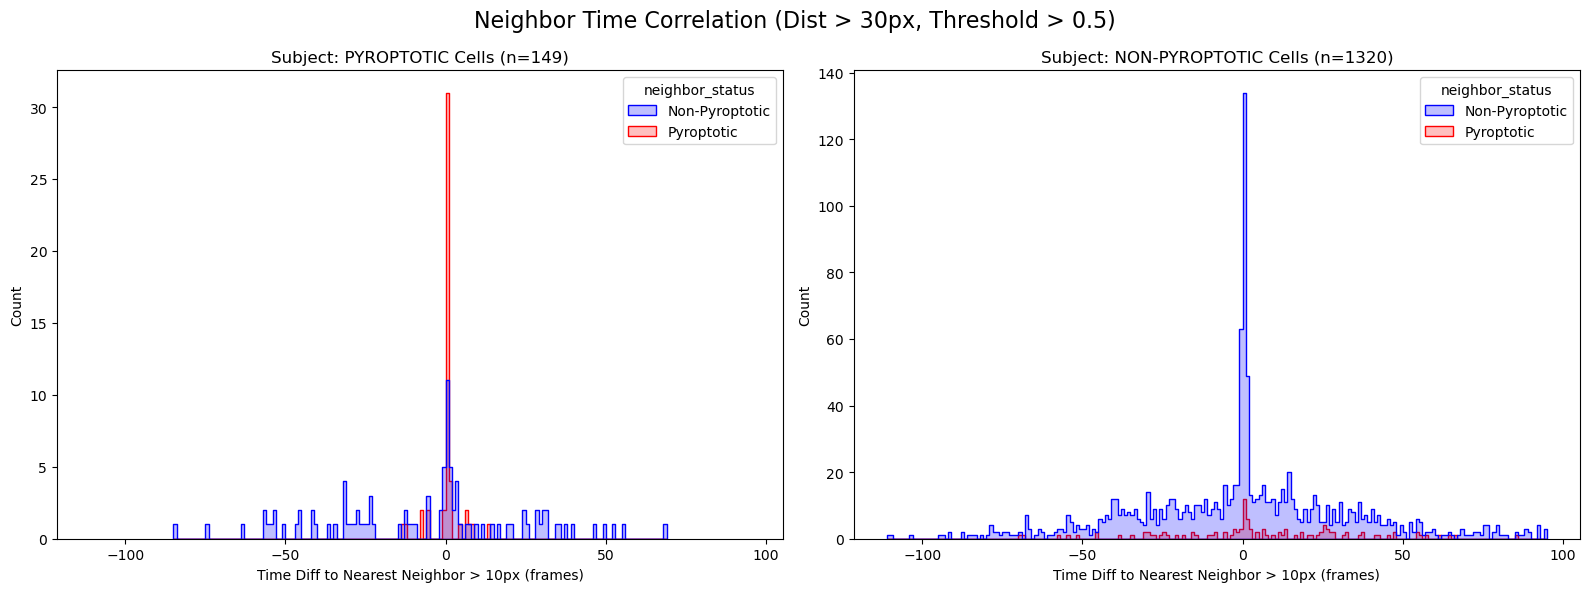

Analyzing: (np.int64(405), 'Cisplatin 10uM', 'A549 GasE KO')


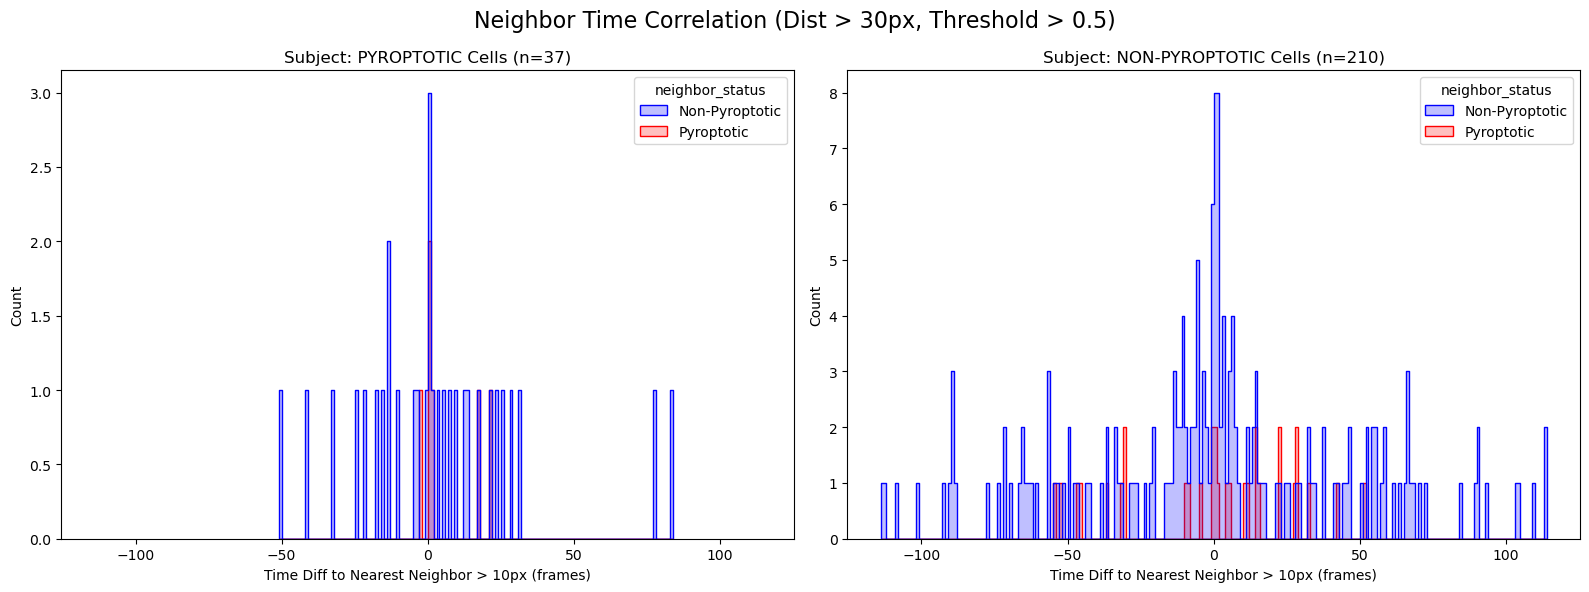

Analyzing: (np.int64(502), 'mock', 'A549 DKO-6')


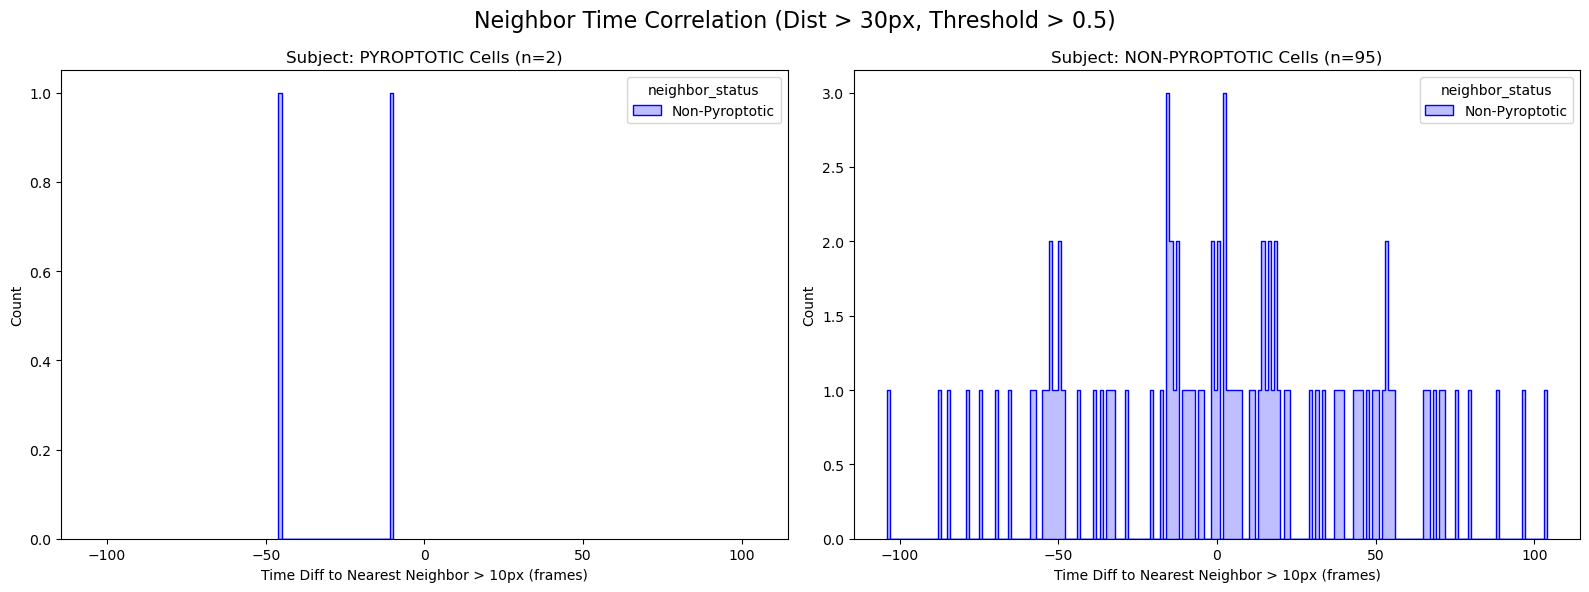

Analyzing: (np.int64(503), 'IAV MS6 MOI 1', 'A549 DKO-6')


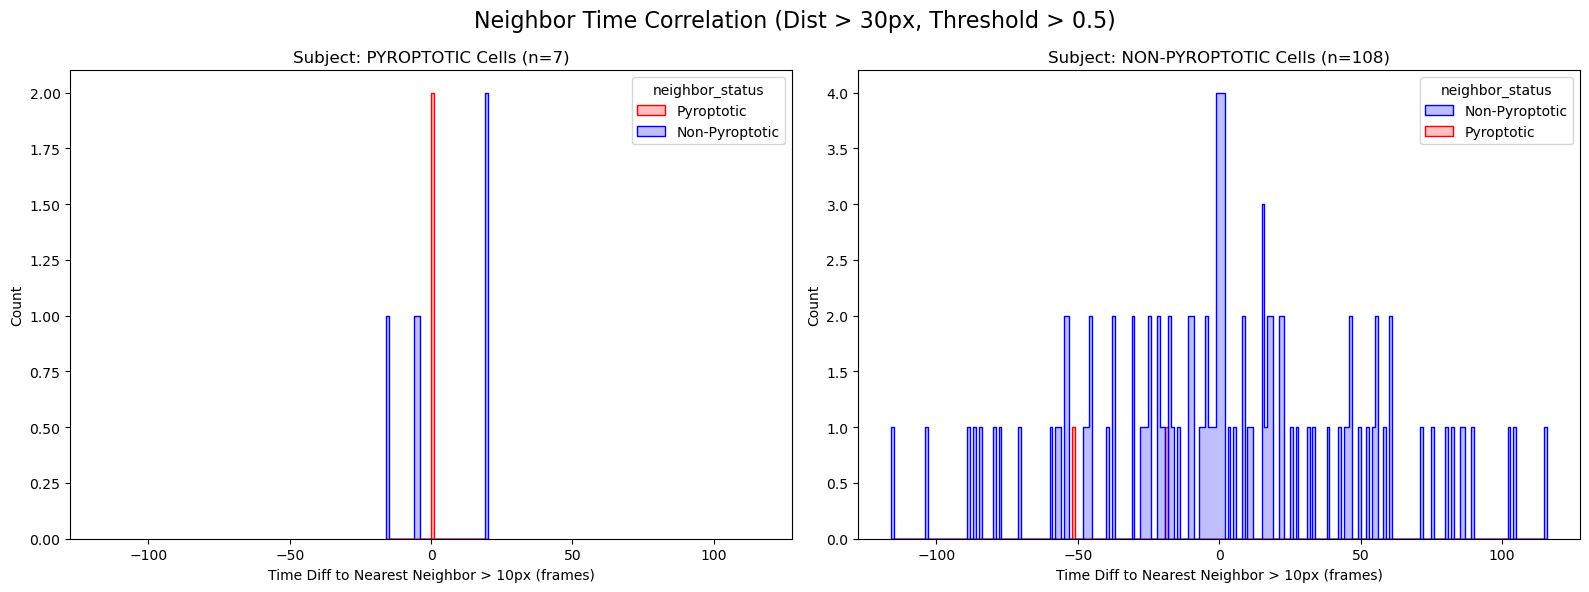

Analyzing: (np.int64(504), 'pIC 0,1', 'A549 DKO-6')


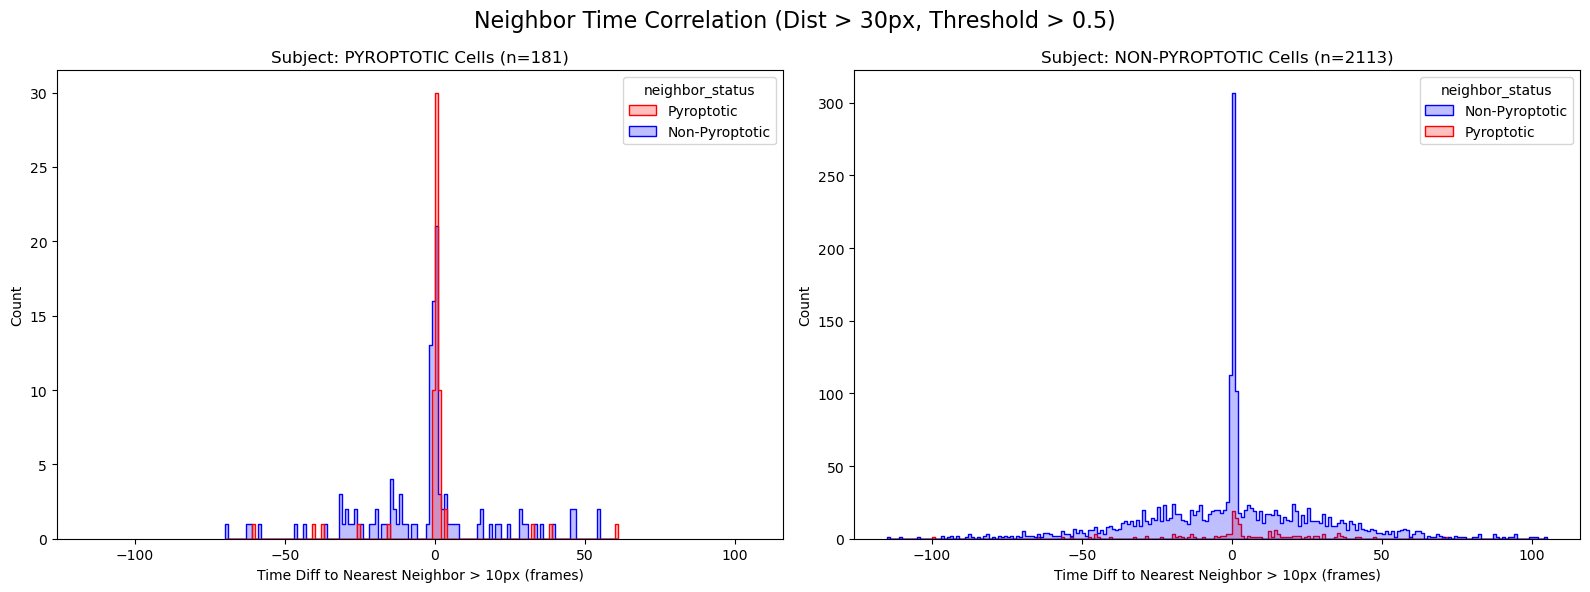

Analyzing: (np.int64(505), 'Cisplatin 10uM', 'A549 DKO-6')


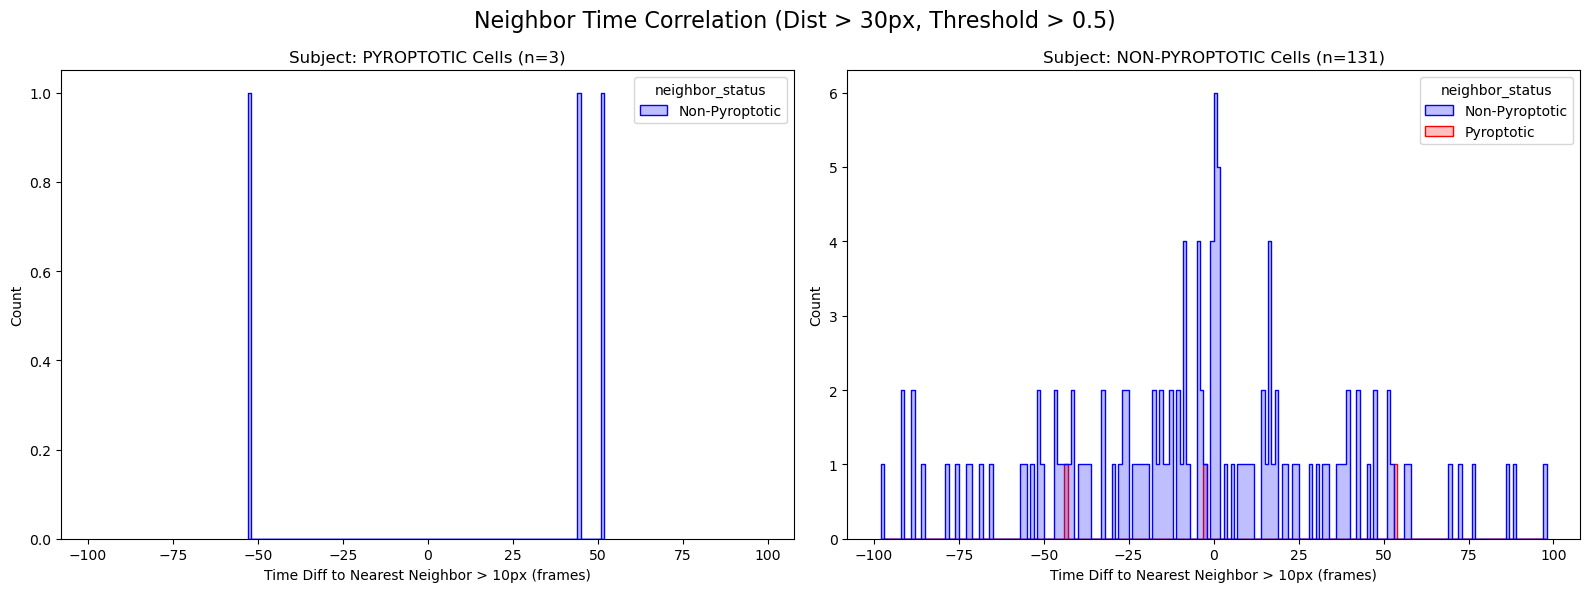

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

def plot_neighbor_time_diffs(df, pred_col, threshold=0.8, min_dist=10):
    # 1. Prepare Data
    work_df = df.copy().reset_index(drop=True)
    
    # Classify cells
    work_df['status'] = np.where(work_df[pred_col] > threshold, 'Pyroptotic', 'Non-Pyroptotic')
    
    # Validation: Need enough points
    if len(work_df) < 2:
        return

    # 2. Find Nearest Neighbors (Spatial only)
    coords = work_df[['center_x', 'center_y']].values
    
    # --- CHANGE: Ask for more neighbors (e.g., 10) so we have backups ---
    # We can't just ask for 2, because if the 2nd one is < 10px, we need the 3rd.
    search_k = min(len(work_df), 10) 
    nbrs = NearestNeighbors(n_neighbors=search_k).fit(coords)
    distances, indices = nbrs.kneighbors(coords)
    
    # 3. Filter Neighbors by Distance
    # We want the FIRST neighbor where distance > min_dist
    # indices[:, 0] is self (dist 0). We check columns 1 to search_k.
    
    valid_neighbor_indices = []
    valid_rows = []

    for i in range(len(coords)):
        found = False
        # Iterate through the neighbors found (starting from 1, skipping self)
        for k in range(1, search_k):
            dist = distances[i, k]
            idx = indices[i, k]
            
            # CHECK: Is the distance bigger than our limit?
            if dist > min_dist:
                valid_neighbor_indices.append(idx)
                valid_rows.append(i) # Keep track of which row this belongs to
                found = True
                break # Stop looking, we found the nearest VALID neighbor
        
        # Note: If no neighbor > 10 is found among the top 10, this cell is ignored.
    
    # Filter work_df to only keep rows where we found a valid neighbor
    if not valid_rows:
        print("No neighbors found satisfying distance criteria.")
        return
        
    work_df = work_df.iloc[valid_rows].copy()
    
    # 4. Retrieve Neighbor Info using the lists we built
    neighbor_data = work_df.iloc[valid_neighbor_indices].reset_index(drop=True)
    
    # We must match the indices. Since valid_neighbor_indices corresponds to the 
    # rows in 'work_df' (which we just filtered), we can assign directly if we align them.
    # However, simpler is to just assign values arrays:
    
    work_df['neighbor_status'] = neighbor_data['status'].values
    work_df['neighbor_time'] = neighbor_data['time_point_index'].values
    
    # Calculate Time Difference (No Absolute Value)
    work_df['time_diff'] = work_df['time_point_index'] - work_df['neighbor_time']

    # 5. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=False)
    
    # --- Plot A: Focus on PYROPTOTIC Cells ---
    pyro_cells = work_df[work_df['status'] == 'Pyroptotic']
    
    if not pyro_cells.empty:
        sns.histplot(
            data=pyro_cells,
            x='time_diff',
            hue='neighbor_status',
            multiple='layer',
            palette={'Pyroptotic': 'red', 'Non-Pyroptotic': 'blue'},
            binwidth=1,
            element='step',
            ax=axes[0]
        )
        axes[0].set_title(f"Subject: PYROPTOTIC Cells (n={len(pyro_cells)})")
        axes[0].set_xlabel("Time Diff to Nearest Neighbor > 10px (frames)")
        axes[0].set_ylabel("Count")
    
    # --- Plot B: Focus on NON-PYROPTOTIC Cells ---
    non_pyro_cells = work_df[work_df['status'] == 'Non-Pyroptotic']
    
    if not non_pyro_cells.empty:
        sns.histplot(
            data=non_pyro_cells,
            x='time_diff',
            hue='neighbor_status',
            multiple='layer',
            palette={'Pyroptotic': 'red', 'Non-Pyroptotic': 'blue'},
            binwidth=1,
            element='step',
            ax=axes[1]
        )
        axes[1].set_title(f"Subject: NON-PYROPTOTIC Cells (n={len(non_pyro_cells)})")
        axes[1].set_xlabel("Time Diff to Nearest Neighbor > 10px (frames)")
        axes[1].set_ylabel("Count")

    plt.suptitle(f"Neighbor Time Correlation (Dist > {min_dist}px, Threshold > {threshold})", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- Run the analysis ---
# Looping through your groups
for id_keys, well_data in tracks[(tracks['track_length']>20)&(tracks['track_length']<119)].groupby(['well', 'Compound', 'Cell Type']):
    # Unpack keys safely
    print(f"Analyzing: {id_keys}")
    
    # Call function with new min_dist parameter
    plot_neighbor_time_diffs(well_data, pred_col='prediction', threshold=0.5, min_dist=30)